# **Project Name**    - Student Performance Prediction Using Machine Learning and Behavioral Analytics



##### **Project Type**    - Machine Learning | Predictive Analytics | Educational Data Mining
##### **Contribution**    - Team
##### **Team Member 1 -**
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

Student performance prediction has become an important research area in educational data mining and learning analytics. Educational institutions collect large amounts of student data such as study hours, attendance, sleep patterns, extracurricular activities, stress levels, and social engagement. Analyzing this data can help institutions identify students at risk of poor academic performance and implement early interventions to improve learning outcomes.

This project aims to develop a machine learning based predictive model capable of accurately forecasting student academic performance using behavioral, lifestyle, and academic attributes. By leveraging modern machine learning techniques, the system identifies key factors that influence student success and provides actionable insights for educators and institutions.

The dataset used in this study contains various student-related attributes including study hours, sleep hours, extracurricular participation, stress levels, physical activity, social engagement, and attendance records. The target variable represents student academic performance in terms of CGPA or grade classification. The data is first processed through an extensive data preprocessing pipeline including missing value treatment, outlier detection, categorical encoding, feature scaling, and feature engineering.

Exploratory Data Analysis (EDA) is performed to understand the distribution of variables and relationships between student behaviors and academic outcomes. Various visualization techniques such as histograms, boxplots, correlation heatmaps, scatter plots, and pair plots are used to uncover meaningful insights from the dataset. These visualizations help identify patterns such as the impact of study time, stress level, sleep patterns, and physical activity on academic performance.

After data preprocessing and exploratory analysis, multiple machine learning algorithms are implemented to build predictive models. Algorithms including Linear Regression, Random Forest, Gradient Boosting, Support Vector Machine, and XGBoost are evaluated to determine the most effective model for predicting student performance. Hyperparameter tuning techniques such as Grid Search Cross Validation are used to optimize model parameters and improve predictive accuracy.

Model performance is evaluated using various evaluation metrics including R² Score, Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE). These metrics provide insights into the reliability and predictive capability of the models. Additionally, feature importance analysis is conducted to identify the most influential factors affecting student performance.

The final optimized model can assist educators and academic administrators in identifying students who may require additional support. Early identification enables timely academic interventions, personalized learning strategies, and improved educational outcomes.

Overall, this research demonstrates how machine learning techniques can be effectively applied in educational analytics to improve student success rates and institutional decision-making processes.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Educational institutions face challenges in identifying students who may struggle academically before their performance significantly declines. Traditional evaluation methods often rely on end-semester results, which makes it difficult to provide timely support and intervention.

With the increasing availability of educational and behavioral data, machine learning provides an opportunity to analyze multiple factors that influence academic performance and build predictive models capable of forecasting student outcomes.

The objective of this project is to develop a machine learning model that predicts student academic performance based on factors such as study habits, attendance, sleep patterns, stress levels, extracurricular involvement, and lifestyle behaviors. By analyzing these variables, the model aims to identify key predictors of academic success and provide insights that can help educators implement early intervention strategies.

The ultimate goal is to improve student success rates by enabling data-driven decision making in educational institutions.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [414]:
# ==========================================
# Basic Libraries
# ==========================================
import numpy as np
import pandas as pd

# ==========================================
# Data Visualization
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# ==========================================
# Machine Learning Libraries
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# ==========================================
# Preprocessing
# ==========================================
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

# ==========================================
# Feature Selection
# ==========================================
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import RFE

# ==========================================
# Machine Learning Models
# ==========================================
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.svm import SVR

# Advanced Boosting
from xgboost import XGBRegressor

# ==========================================
# Evaluation Metrics
# ==========================================
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# ==========================================
# Explainable AI
# ==========================================
import shap

# ==========================================
# Ignore Warnings
# ==========================================
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [415]:
# ==========================================
# Load Dataset
# ==========================================

# Replace with your dataset path
df = pd.read_csv("student_performance.csv")

# create a copy for safety
data = df.copy()

### Dataset First View

In [416]:
# ==========================================
# Dataset First Look
# ==========================================

# View first 10 rows
data.head(10)

,University Admission year,Gender,Age,H.S.C passing year,Program,Current Semester,Do you have meritorious scholarship ?,Do you use University transportation?,How many hour do you study daily?,How many times do you seat for study in a day?,...,What is you interested area?,What is your relationship status?,Are you engaged with any co-curriculum activities?,With whom you are living with?,Do you have any health issues?,What was your previous SGPA?,Do you have any physical disabilities?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly family income?
0,2018,Male,24,2016,BCSE,12,Yes,No,3,2,...,Data Schince,Single,Yes,Bachelor,No,2.68,No,3.15,75,25000
1,2021,Male,22,2020,BCSE,4,Yes,Yes,3,2,...,Event management,Single,Yes,Family,No,2.68,No,3.15,36,100000
2,2020,Female,21,2019,BCSE,5,No,No,3,3,...,Software,Single,No,Bachelor,No,2.68,No,3.15,50,50000
3,2021,Male,20,2020,BCSE,4,Yes,No,1,3,...,Artificial Intelligence,Single,No,Bachelor,Yes,2.68,No,3.15,36,62488
4,2021,Male,22,2019,BCSE,4,Yes,No,3,1,...,Software,Relationship,No,Bachelor,Yes,2.68,No,3.15,36,50000
5,2021,Male,20,2020,BCSE,4,Yes,Yes,2,2,...,Software,Single,Yes,Family,No,2.68,No,3.15,36,30000
6,2021,Male,22,2018,BCSE,4,Yes,No,2,4,...,Software,Single,No,Bachelor,Yes,2.68,No,3.15,36,20000
7,2021,Female,22,2019,BCSE,4,Yes,No,2,2,...,NETWORKING,Single,No,Bachelor,No,3.80,No,3.64,35,32500
8,2021,Male,20,2020,BCSE,4,Yes,No,3,2,...,Software,Single,No,Bachelor,No,2.68,No,3.15,36,20000
9,2021,Female,22,2020,BCSE,4,Yes,Yes,5,2,...,Artificial Intelligence,Single,No,Family,No,2.68,No,3.15,36,25000


### Dataset Rows & Columns count

In [417]:
# ==========================================
# Dataset Rows & Columns count
# ==========================================

data.shape

(1194, 31)

### Dataset Information

In [418]:
# Dataset Info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 31 columns):
 #   Column                                                                     Non-Null Count  Dtype  
---  ------                                                                     --------------  -----  
 0   University Admission year                                                  1194 non-null   int64  
 1   Gender                                                                     1194 non-null   object 
 2   Age                                                                        1194 non-null   int64  
 3   H.S.C passing year                                                         1194 non-null   int64  
 4   Program                                                                    1194 non-null   object 
 5   Current Semester                                                           1194 non-null   int64  
 6   Do you have meritorious scholarship ?                   

#### Duplicate Values

In [419]:
# Check duplicate rows
data.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [420]:
# Missing Values/Null Values Count
data.isnull().sum()

,0
University Admission year,0
Gender,0
Age,0
H.S.C passing year,0
Program,0
Current Semester,0
Do you have meritorious scholarship ?,0
Do you use University transportation?,0
How many hour do you study daily?,0
How many times do you seat for study in a day?,0


###Target Variable Distribution

<Axes: xlabel='What is your current CGPA?', ylabel='Count'>

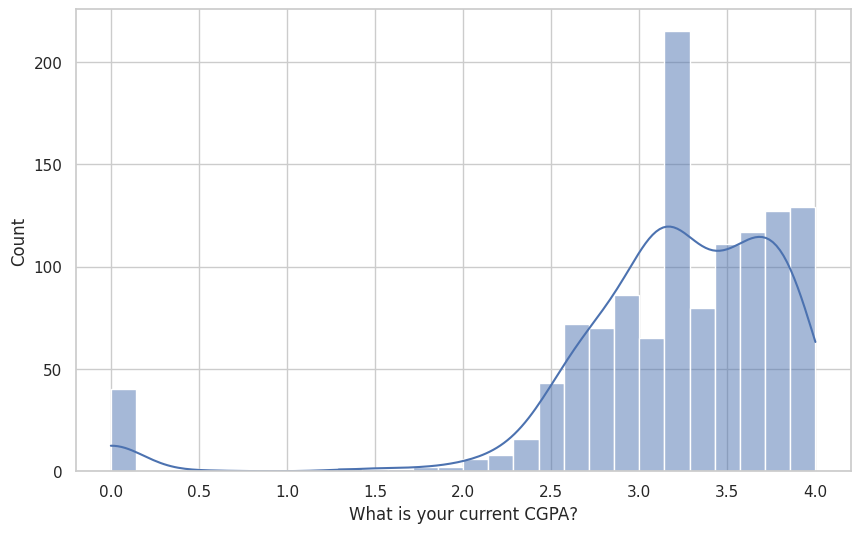

In [421]:
sns.histplot(data["What is your current CGPA?"], kde=True)

###Feature Type Summary

In [422]:
numerical_features = data.select_dtypes(include=['int64','float64']).columns
categorical_features = data.select_dtypes(include=['object']).columns

### What did you know about your dataset?

The dataset contains information related to students' academic, behavioral, and demographic characteristics, which can be used to analyze and predict student academic performance. After exploring the dataset, it was found that the dataset contains 1194 records and 31 features, representing individual student responses collected through a survey or institutional data collection.

The dataset includes both numerical and categorical variables. Numerical variables include attributes such as age, daily study hours, number of study sessions per day, time spent on social media, hours spent on skill development, previous SGPA, current CGPA, completed credits, and monthly family income. These variables represent measurable aspects of student behavior and academic performance. On the other hand, categorical variables include features such as gender, program, scholarship status, transportation usage, preferred learning mode, smartphone usage, computer ownership, English proficiency level, attendance level, relationship status, and participation in co-curricular activities.

The dataset appears to have good data quality. The analysis of missing values indicates that almost all columns contain complete data, with only one column (“What are the skills do you have?”) having a single missing value. Additionally, the dataset does not contain duplicate records, meaning that each row represents a unique student entry.

From the statistical summary, it is observed that the average age of students is approximately 21 years, and the average CGPA is around 3.16. The dataset also reveals variations in study habits, social media usage, and skill development activities among students, which may influence academic performance.

The presence of both behavioral and academic attributes provides a strong foundation for building a machine learning model to predict student academic performance, with Current CGPA acting as the target variable. These features can help uncover patterns and relationships that influence student success and allow predictive models to identify key factors affecting academic outcomes.

Overall, the dataset is sufficiently rich and structured for performing exploratory data analysis, feature engineering, and machine learning model development aimed at predicting student performance.

## ***2. Understanding Your Variables***

In [423]:
# Display all column names
for col in data.columns:
    print(col)

University Admission year
Gender
Age
H.S.C passing year
Program
Current Semester
Do you have meritorious scholarship ?
Do you use University transportation?
How many hour do you study daily?
How many times do you seat for study in a day?
What is your preferable learning mode?
Do you use smart phone?
Do you have personal Computer?
How many hour do you spent daily in social media?
Status of your English language proficiency
Average attendance on class
Did you ever fall in probation?
Did you ever got suspension?
Do you attend in teacher consultancy for any kind of academical problems?
What are the skills do you have ?
How many hour do you spent daily on your skill development?
What is you interested area?
What is your relationship status?
Are you engaged with any co-curriculum activities?
With whom you are living with?
Do you have any health issues?
What was your previous SGPA?
Do you have any physical disabilities?
What is your current CGPA?
How many Credit did you have completed?
What i

In [424]:
# Dataset Describe
data.describe().T

,count,mean,std,min,25%,50%,75%,max
University Admission year,1194.0,2020.515075,1.354954,2013.0,2020.0,2021.00,2022.00,2023.0
Age,1194.0,21.343384,1.613338,18.0,20.0,21.00,22.00,27.0
H.S.C passing year,1194.0,2019.214405,1.380960,2012.0,2019.0,2020.00,2020.00,2028.0
Current Semester,1194.0,6.539363,3.809884,1.0,3.0,7.00,10.00,24.0
How many hour do you study daily?,1194.0,3.131491,1.649597,0.0,2.0,3.00,4.00,13.0
How many times do you seat for study in a day?,1194.0,1.940536,0.856305,0.0,1.0,2.00,2.00,7.0
How many hour do you spent daily in social media?,1194.0,3.289782,2.289547,0.0,2.0,3.00,4.00,20.0
How many hour do you spent daily on your skill development?,1194.0,2.185092,1.296101,0.0,1.0,2.00,3.00,12.0
What was your previous SGPA?,1194.0,2.683945,0.871592,0.0,2.2,2.68,3.38,4.0
What is your current CGPA?,1194.0,3.165603,0.750132,0.0,2.9,3.21,3.67,4.0


### Variables Description

The dataset contains multiple numerical and categorical variables that describe the academic, demographic, and behavioral characteristics of students. The numerical variables provide statistical insights into students’ academic progress and lifestyle habits.

From the statistical summary, the average student age is approximately 21.34 years, with most students falling within the 20–22 age range, indicating that the dataset primarily represents undergraduate students. The university admission year averages around 2020, suggesting that most students in the dataset enrolled recently. Similarly, the average H.S.C passing year is approximately 2019, which aligns with the expected academic progression of students entering university.

The current semester variable has a mean of approximately 6.54, indicating that the dataset contains students from both early and advanced semesters of their academic programs. The wide range of semesters (1 to 24) suggests that the dataset includes students at different stages of their academic journey.

Study behavior variables show interesting trends. On average, students study approximately 3.13 hours per day and typically sit for study sessions about 1.94 times per day. Social media usage averages around 3.29 hours daily, which may influence academic performance. Additionally, students spend approximately 2.19 hours per day on skill development, indicating engagement in extracurricular learning activities beyond academic coursework.

Academic performance indicators reveal that the average previous SGPA is approximately 2.68, while the average current CGPA is around 3.17, suggesting a moderate improvement in overall academic performance for many students. The CGPA values range between 0 and 4, which aligns with the standard academic grading scale used in many universities.

Regarding academic progress, students have completed an average of approximately 71.84 credit hours, though the distribution is wide, ranging from 0 to 145 credits, reflecting students from different semesters and academic stages.

The monthly family income variable shows significant variability, with an average income of approximately 62,488 units and a maximum value reaching 2,000,000, indicating the presence of high-income outliers in the dataset. This suggests that socioeconomic factors may also play a role in student academic outcomes and may require normalization or transformation during preprocessing.

Overall, the dataset provides a diverse range of academic, behavioral, and socioeconomic attributes that can be used to analyze patterns affecting student performance. The presence of both academic indicators (CGPA, SGPA, credits completed) and lifestyle factors (study hours, social media usage, skill development time) makes this dataset well-suited for building machine learning models aimed at predicting student academic performance.

### Check Unique Values for each variable.

In [425]:
# Check Unique Values for each variable.
for col in data.columns:
    print(f"\nColumn: {col}")
    print(f"Unique values count: {data[col].nunique()}")
    print(data[col].unique())


Column: University Admission year
Unique values count: 11
[2018 2021 2020 2022 2019 2017 2015 2016 2014 2013 2023]

Column: Gender
Unique values count: 2
['Male' 'Female']

Column: Age
Unique values count: 10
[24 22 21 20 19 25 23 26 27 18]

Column: H.S.C passing year
Unique values count: 12
[2016 2020 2019 2018 2021 2017 2022 2012 2014 2015 2028 2013]

Column: Program
Unique values count: 1
['BCSE']

Column: Current Semester
Unique values count: 22
[12  4  5  2 11  8 10 13  9 15 14 21  6  7 22  1 18 17  3 19 16 24]

Column: Do you have meritorious scholarship ?
Unique values count: 2
['Yes' 'No']

Column: Do you use University transportation?
Unique values count: 2
['No' 'Yes']

Column: How many hour do you study daily?
Unique values count: 12
[ 3  1  2  5  6  4  8  7  9  0 10 13]

Column: How many times do you seat for study in a day?
Unique values count: 8
[2 3 1 4 5 7 0 6]

Column: What is your preferable learning mode?
Unique values count: 2
['Offline' 'Online']

Column: Do you u

## 3. ***Data Wrangling***

###Data Wrangling Code

In [426]:
# Create working copy
df = data.copy()

In [427]:
# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("?", "")
    .str.replace(".", "")
)

df.columns

Index(['university_admission_year', 'gender', 'age', 'hsc_passing_year',
       'program', 'current_semester', 'do_you_have_meritorious_scholarship_',
       'do_you_use_university_transportation',
       'how_many_hour_do_you_study_daily',
       'how_many_times_do_you_seat_for_study_in_a_day',
       'what_is_your_preferable_learning_mode', 'do_you_use_smart_phone',
       'do_you_have_personal_computer',
       'how_many_hour_do_you_spent_daily_in_social_media',
       'status_of_your_english_language_proficiency',
       'average_attendance_on_class', 'did_you_ever_fall_in_probation',
       'did_you_ever_got_suspension',
       'do_you_attend_in_teacher_consultancy_for_any_kind_of_academical_problems',
       'what_are_the_skills_do_you_have_',
       'how_many_hour_do_you_spent_daily_on_your_skill_development',
       'what_is_you_interested_area', 'what_is_your_relationship_status',
       'are_you_engaged_with_any_co-curriculum_activities',
       'with_whom_you_are_living_with

In [428]:
df.rename(columns={
    "do_you_have_meritorious_scholarship_": "meritorious_scholarship",
    "what_are_the_skills_do_you_have_": "skills",
    "are_you_engaged_with_any_co-curriculum_activities": "co_curriculum_activity",
    "what_is_you_interested_area": "interested_area",
    "what_is_your_relationship_status": "relationship_status",
    "with_whom_you_are_living_with": "living_with",
    "what_was_your_previous_sgpa": "previous_sgpa",
    "what_is_your_current_cgpa": "cgpa",
    "how_many_hour_do_you_study_daily": "study_hours",
    "how_many_hour_do_you_spent_daily_in_social_media": "social_media_hours",
    "how_many_hour_do_you_spent_daily_on_your_skill_development": "skill_dev_hours",
    "average_attendance_on_class": "attendance",
    "how_many_credit_did_you_have_completed": "completed_credits",
    "what_is_your_monthly_family_income": "family_income"
}, inplace=True)

In [429]:
df.columns

Index(['university_admission_year', 'gender', 'age', 'hsc_passing_year',
       'program', 'current_semester', 'meritorious_scholarship',
       'do_you_use_university_transportation', 'study_hours',
       'how_many_times_do_you_seat_for_study_in_a_day',
       'what_is_your_preferable_learning_mode', 'do_you_use_smart_phone',
       'do_you_have_personal_computer', 'social_media_hours',
       'status_of_your_english_language_proficiency', 'attendance',
       'did_you_ever_fall_in_probation', 'did_you_ever_got_suspension',
       'do_you_attend_in_teacher_consultancy_for_any_kind_of_academical_problems',
       'skills', 'skill_dev_hours', 'interested_area', 'relationship_status',
       'co_curriculum_activity', 'living_with',
       'do_you_have_any_health_issues', 'previous_sgpa',
       'do_you_have_any_physical_disabilities', 'cgpa', 'completed_credits',
       'family_income'],
      dtype='object')

In [430]:
df["do_you_have_any_health_issues"] = df["do_you_have_any_health_issues"].replace({
    "n": "no"
})
df["do_you_have_any_health_issues"].fillna(
    df["do_you_have_any_health_issues"].mode()[0],
    inplace=True
)

In [431]:
binary_cols = [
"meritorious_scholarship",
"do_you_use_university_transportation",
"do_you_use_smart_phone",
"do_you_have_personal_computer",
"did_you_ever_fall_in_probation",
"did_you_ever_got_suspension",
"do_you_attend_in_teacher_consultancy_for_any_kind_of_academical_problems",
"co_curriculum_activity",
"do_you_have_any_health_issues",
"do_you_have_any_physical_disabilities"
]

for col in binary_cols:
    df[col] = df[col].str.lower().map({"yes":1,"no":0})

In [432]:
df["gender"] = df["gender"].str.lower().map({
    "male": 1,
    "female": 0
})

In [433]:
df["skills"] = df["skills"].fillna("unknown")

In [434]:
def clean_attendance(x):
    if "-" in str(x):
        nums = x.split("-")
        return (float(nums[0]) + float(nums[1])) / 2
    else:
        return float(x)

df["attendance"] = df["attendance"].apply(clean_attendance)

In [435]:
df["interested_area"] = df["interested_area"].str.lower()

df["interested_area"] = df["interested_area"].replace({
    "data schince":"data science",
    "web developing":"web development",
    "cyber security":"cybersecurity",
    "syber security":"cybersecurity"
})

In [436]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 31 columns):
 #   Column                                                                    Non-Null Count  Dtype  
---  ------                                                                    --------------  -----  
 0   university_admission_year                                                 1194 non-null   int64  
 1   gender                                                                    1194 non-null   int64  
 2   age                                                                       1194 non-null   int64  
 3   hsc_passing_year                                                          1194 non-null   int64  
 4   program                                                                   1194 non-null   object 
 5   current_semester                                                          1194 non-null   int64  
 6   meritorious_scholarship                                         

,university_admission_year,gender,age,hsc_passing_year,program,current_semester,meritorious_scholarship,do_you_use_university_transportation,study_hours,how_many_times_do_you_seat_for_study_in_a_day,...,interested_area,relationship_status,co_curriculum_activity,living_with,do_you_have_any_health_issues,previous_sgpa,do_you_have_any_physical_disabilities,cgpa,completed_credits,family_income
0,2018,1,24,2016,BCSE,12,1,0,3,2,...,data science,Single,1,Bachelor,0.0,2.68,0,3.15,75,25000
1,2021,1,22,2020,BCSE,4,1,1,3,2,...,event management,Single,1,Family,0.0,2.68,0,3.15,36,100000
2,2020,0,21,2019,BCSE,5,0,0,3,3,...,software,Single,0,Bachelor,0.0,2.68,0,3.15,50,50000
3,2021,1,20,2020,BCSE,4,1,0,1,3,...,artificial intelligence,Single,0,Bachelor,1.0,2.68,0,3.15,36,62488
4,2021,1,22,2019,BCSE,4,1,0,3,1,...,software,Relationship,0,Bachelor,1.0,2.68,0,3.15,36,50000


### What all manipulations have you done and insights you found?

In the data wrangling stage, several preprocessing steps were performed to make the dataset clean, consistent, and ready for analysis and machine learning modeling. First, column names were standardized and simplified to improve readability and ensure easier manipulation during analysis.

Next, categorical variables containing binary responses such as scholarship status, transportation usage, smartphone usage, personal computer ownership, probation history, suspension history, co-curricular participation, and physical disabilities were converted into numerical format where 1 represents Yes and 0 represents No. This conversion allows machine learning algorithms to interpret these features effectively.

The gender variable was also encoded into numerical format with Male represented as 1 and Female as 0.

The attendance column contained mixed formats including numeric values and ranges (e.g., "94–98"). These ranges were converted into their average numeric values so that attendance could be treated as a continuous numerical variable.

Minor inconsistencies in categorical text values were also standardized by converting them to lowercase and correcting spelling variations in certain fields such as the interested area column. Additionally, missing values in the health issues column were handled using the most frequent value to maintain dataset completeness.

After performing these preprocessing steps, the dataset became well-structured with numerical and categorical variables properly organized, allowing for effective exploratory data analysis and machine learning model development.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

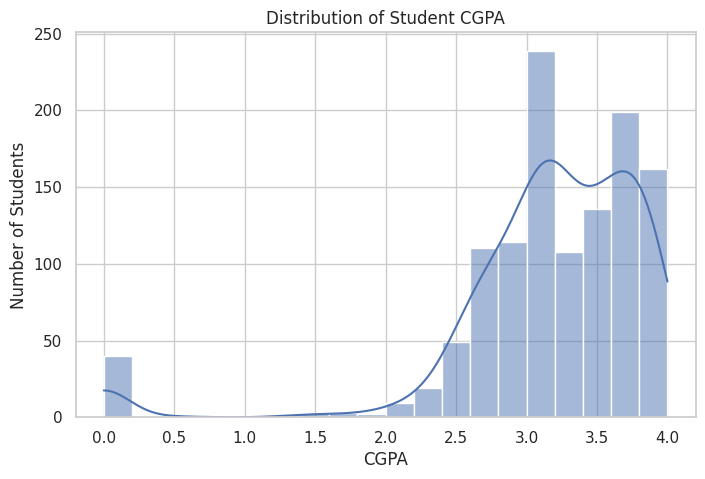

In [437]:
plt.figure(figsize=(8,5))

sns.histplot(df["cgpa"], bins=20, kde=True)

plt.title("Distribution of Student CGPA")
plt.xlabel("CGPA")
plt.ylabel("Number of Students")

plt.show()

In [438]:
print("CGPA Summary Statistics")
print(df["cgpa"].describe())

print("\nCGPA Value Counts (rounded)")
print(df["cgpa"].round(1).value_counts().sort_index())

CGPA Summary Statistics
count    1194.000000
mean        3.165603
std         0.750132
min         0.000000
25%         2.900000
50%         3.210000
75%         3.670000
max         4.000000
Name: cgpa, dtype: float64

CGPA Value Counts (rounded)
cgpa
0.0     39
0.1      1
0.5      1
1.4      3
1.6      1
1.8      2
1.9      1
2.0      3
2.1      4
2.2      8
2.3      5
2.4     18
2.5     24
2.6     50
2.7     46
2.8     58
2.9     58
3.0     55
3.1     38
3.2    204
3.3     35
3.4     83
3.5     57
3.6     89
3.7     73
3.8    109
3.9     91
4.0     38
Name: count, dtype: int64


##### 1. Why did you pick the specific chart?

The histogram distribution chart was selected to analyze the overall distribution of the target variable, Current CGPA. Understanding the distribution of the target variable is important before building a machine learning model because it helps identify patterns such as skewness, concentration of values, and possible outliers. This chart allows us to observe how student academic performance is spread across the dataset.

##### 2. What is/are the insight(s) found from the chart?

The distribution of CGPA shows that most students have a CGPA between 3.0 and 3.8, with the highest concentration around 3.2. The mean CGPA is approximately 3.17, indicating that the average academic performance of students is moderately high.

The dataset also contains a small number of students with very low CGPA values, including some values close to 0, which may represent students with extremely poor academic performance or incomplete records. Additionally, a significant number of students have CGPAs close to 4.0, indicating strong academic performance among a portion of the students.

Overall, the distribution suggests that the majority of students perform in the above-average academic range, while a smaller group struggles academically.

##### 3. How can these insights be useful?

These insights help institutions understand the overall academic performance distribution of students. Since most students fall within a relatively high CGPA range, universities may focus on identifying the smaller group of students with low CGPA values and provide targeted academic support such as tutoring, mentorship programs, or counseling. This can help improve overall academic success rates and reduce academic probation or dropout risks.

#### Chart - 2

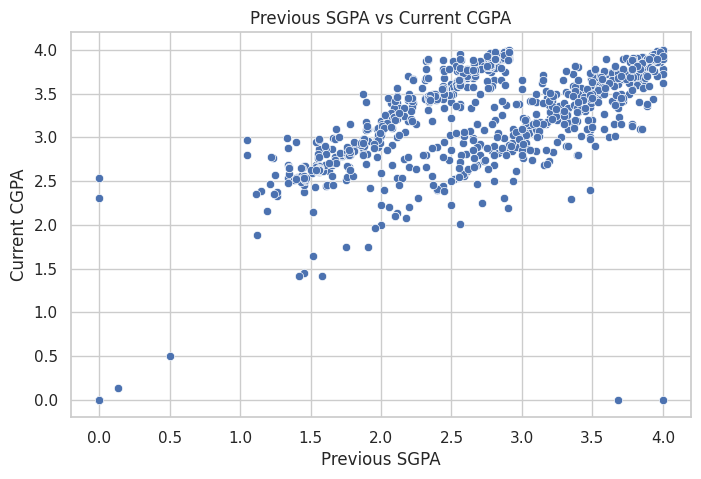

In [439]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df["previous_sgpa"], y=df["cgpa"])

plt.title("Previous SGPA vs Current CGPA")
plt.xlabel("Previous SGPA")
plt.ylabel("Current CGPA")

plt.show()

In [440]:
print("Correlation between Previous SGPA and Current CGPA:")
print(df[["previous_sgpa","cgpa"]].corr())

print("\nAverage CGPA by Previous SGPA range")

df["sgpa_group"] = pd.cut(df["previous_sgpa"], bins=5)

print(df.groupby("sgpa_group")["cgpa"].mean())

Correlation between Previous SGPA and Current CGPA:
               previous_sgpa      cgpa
previous_sgpa       1.000000  0.755062
cgpa                0.755062  1.000000

Average CGPA by Previous SGPA range
sgpa_group
(-0.004, 0.8]    0.133415
(0.8, 1.6]       2.565889
(1.6, 2.4]       2.981239
(2.4, 3.2]       3.320907
(3.2, 4.0]       3.570917
Name: cgpa, dtype: float64


##### 1. Why did you pick the specific chart?

A scatter plot was chosen to analyze the relationship between Previous SGPA and Current CGPA because both variables are numerical and represent academic performance indicators. This chart helps visualize whether past academic performance influences current performance, which is an important factor when predicting student success using machine learning models.

##### 2. What is/are the insight(s) found from the chart?

The correlation between Previous SGPA and Current CGPA is approximately 0.76, indicating a strong positive relationship between these two variables. This means that students who performed well in their previous semester tend to maintain high academic performance in their current semester.

Additionally, the grouped analysis shows a clear upward trend. Students with very low previous SGPA values (below 0.8) have extremely low average CGPA values, while students with previous SGPA values above 3.2 achieve an average CGPA of approximately 3.57. This confirms that past academic performance is a strong predictor of current academic outcomes.

##### 3. How can these insights be useful?

This finding suggests that previous academic performance is one of the most important indicators of future student success. Educational institutions can use previous SGPA data to identify students who may be at academic risk early in the semester. By identifying these students in advance, universities can provide additional academic support, tutoring programs, or mentorship initiatives to improve student outcomes.

For machine learning models, this variable is likely to be a highly influential predictor feature for predicting student performance.

#### Chart - 3

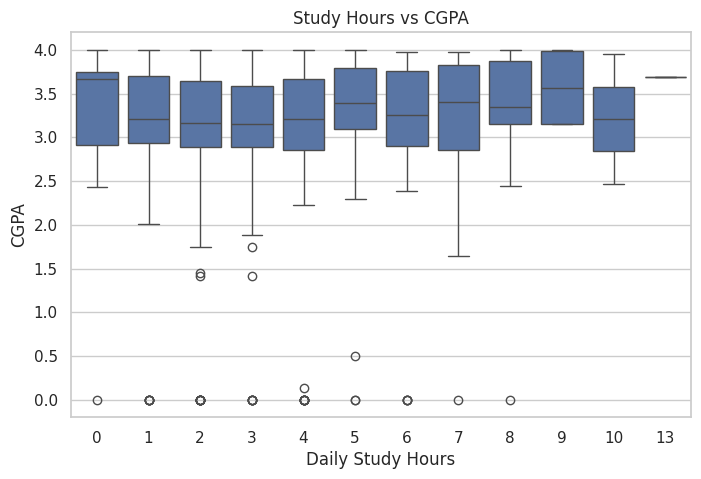

In [441]:
plt.figure(figsize=(8,5))

sns.boxplot(x="study_hours", y="cgpa", data=df)

plt.title("Study Hours vs CGPA")
plt.xlabel("Daily Study Hours")
plt.ylabel("CGPA")

plt.show()

In [442]:
print("Correlation between Study Hours and CGPA:")
print(df[["study_hours","cgpa"]].corr())

print("\nAverage CGPA by Study Hours")

print(
df.groupby("study_hours")["cgpa"]
.mean()
.sort_index()
)

Correlation between Study Hours and CGPA:
             study_hours      cgpa
study_hours     1.000000  0.023696
cgpa            0.023696  1.000000

Average CGPA by Study Hours
study_hours
0     3.115556
1     3.173462
2     3.151302
3     3.152345
4     3.122762
5     3.301452
6     3.108361
7     3.128947
8     3.210000
9     3.570000
10    3.210000
13    3.690000
Name: cgpa, dtype: float64


##### 1. Why did you pick the specific chart?

This chart was chosen to examine the relationship between daily study hours and students' academic performance (CGPA). Study habits are commonly believed to influence academic outcomes, so analyzing this relationship helps determine whether increased study time leads to improved academic performance.

##### 2. What is/are the insight(s) found from the chart?

The correlation between study hours and CGPA is approximately 0.02, which indicates an extremely weak positive relationship. This suggests that simply studying more hours per day does not strongly guarantee better academic performance.

The average CGPA values across different study-hour groups remain relatively similar, generally ranging between 3.1 and 3.3. Although some higher study-hour categories show slightly higher CGPA values, the difference is not significant. This indicates that study quality, learning strategies, and other factors may play a more important role than just the number of hours spent studying.

##### 3. What does this imply for understanding student performance?

This insight suggests that academic performance may not depend solely on the amount of time students spend studying. Other factors such as previous academic background, attendance, learning methods, stress levels, and skill development may have a stronger influence on student performance. Therefore, institutions and educators should focus on effective learning strategies rather than only encouraging longer study hours.

#### Chart - 4

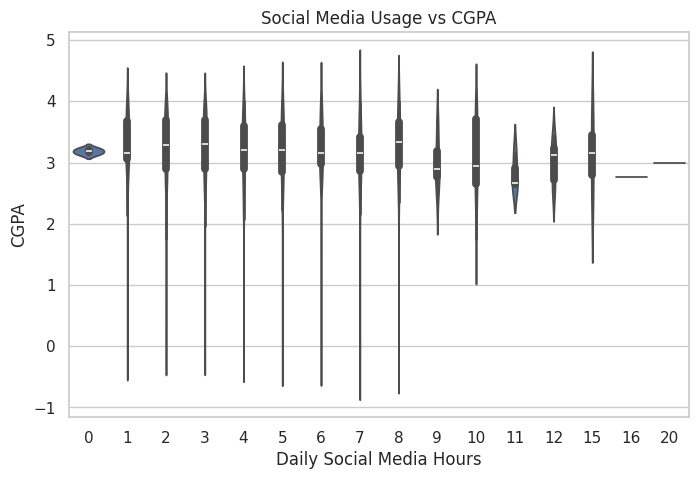

In [443]:
plt.figure(figsize=(8,5))

sns.violinplot(x="social_media_hours", y="cgpa", data=df)

plt.title("Social Media Usage vs CGPA")
plt.xlabel("Daily Social Media Hours")
plt.ylabel("CGPA")

plt.show()

In [444]:
print("Correlation between Social Media Hours and CGPA:")
print(df[["social_media_hours","cgpa"]].corr())

print("\nAverage CGPA by Social Media Usage")

print(
df.groupby("social_media_hours")["cgpa"]
.mean()
.sort_index()
)

Correlation between Social Media Hours and CGPA:
                    social_media_hours      cgpa
social_media_hours            1.000000 -0.052876
cgpa                         -0.052876  1.000000

Average CGPA by Social Media Usage
social_media_hours
0     3.185000
1     3.179124
2     3.195575
3     3.197543
4     3.125000
5     3.114684
6     3.165263
7     2.970000
8     3.194828
9     2.995000
10    3.060625
11    2.823333
12    3.013750
15    3.110000
16    2.770000
20    2.990000
Name: cgpa, dtype: float64


##### 1. Why did you pick the specific chart?

This chart was selected to analyze the relationship between time spent on social media and academic performance (CGPA). Social media usage is often considered a potential distraction for students, so understanding its impact on academic outcomes is important.

##### 2. What is/are the insight(s) found from the chart?

The correlation between social media hours and CGPA is approximately -0.05, indicating a very weak negative relationship. This suggests that increased social media usage may slightly reduce academic performance, but the effect is minimal.

The average CGPA values across different social media usage levels remain relatively close to each other. However, students who spend extremely high amounts of time on social media (10+ hours) tend to show slightly lower CGPA values compared to moderate users.

##### 3. What does this imply for understanding student performance?

This result suggests that moderate social media usage does not significantly harm academic performance, but excessive usage may begin to negatively affect students' focus and productivity. Educational institutions may encourage students to maintain balanced digital habits to prevent potential distractions from academic activities.

#### Chart - 5

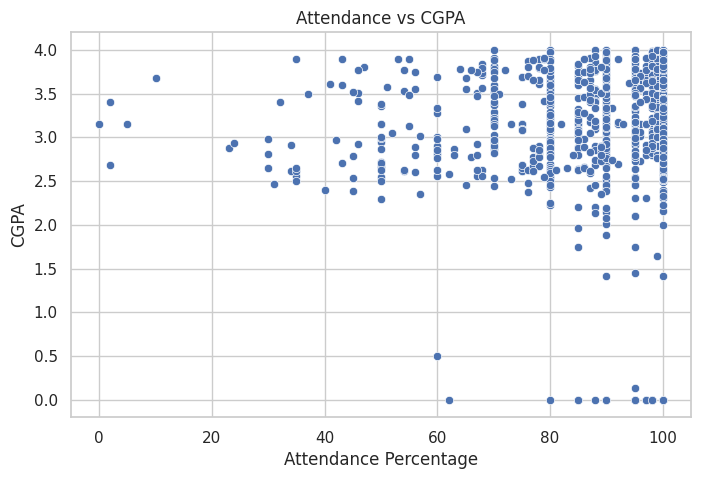

In [445]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df["attendance"], y=df["cgpa"])

plt.title("Attendance vs CGPA")
plt.xlabel("Attendance Percentage")
plt.ylabel("CGPA")

plt.show()

In [446]:
print("Correlation between Attendance and CGPA:")
print(df[["attendance","cgpa"]].corr())

print("\nAverage CGPA by Attendance Range")

df["attendance_group"] = pd.cut(df["attendance"], bins=5)

print(
df.groupby("attendance_group")["cgpa"]
.mean()
)

Correlation between Attendance and CGPA:
            attendance      cgpa
attendance    1.000000  0.064707
cgpa          0.064707  1.000000

Average CGPA by Attendance Range
attendance_group
(-0.1, 20.0]     3.212000
(20.0, 40.0]     2.847647
(40.0, 60.0]     3.025167
(60.0, 80.0]     3.137615
(80.0, 100.0]    3.187640
Name: cgpa, dtype: float64


##### 1. Why did you pick the specific chart?

Attendance was analyzed because it is widely considered an important indicator of student engagement and academic commitment. This chart helps examine whether students who attend classes more regularly tend to achieve higher CGPA values.

##### 2. What is/are the insight(s) found from the chart?

The correlation between attendance and CGPA is approximately 0.06, indicating a weak positive relationship. Students with higher attendance generally tend to achieve slightly better CGPA values.

From the grouped analysis, students with attendance above 80% have the highest average CGPA (around 3.19), while students with lower attendance levels tend to have slightly lower CGPA values. This indicates that regular class participation may contribute to better academic outcomes.

##### 3. What does this imply for understanding student performance?

These findings suggest that consistent attendance may play a supportive role in academic success. While the relationship is not extremely strong, attending classes regularly can help students better understand course material, participate in discussions, and maintain academic discipline. Encouraging students to maintain high attendance levels could therefore contribute to improved academic performance.

#### Chart - 6

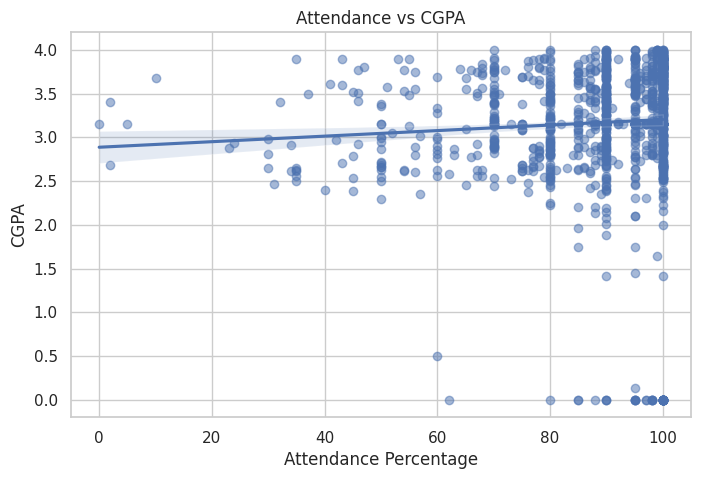

In [447]:
plt.figure(figsize=(8,5))

sns.regplot(x="attendance", y="cgpa", data=df, scatter_kws={"alpha":0.5})

plt.title("Attendance vs CGPA")
plt.xlabel("Attendance Percentage")
plt.ylabel("CGPA")

plt.show()

In [448]:
print("Correlation between Attendance and CGPA")
print(df[["attendance","cgpa"]].corr())

print("\nAverage CGPA by Attendance Quartiles")

attendance_groups = pd.qcut(df["attendance"], 4, duplicates="drop")

print(df.groupby(attendance_groups)["cgpa"].mean())

Correlation between Attendance and CGPA
            attendance      cgpa
attendance    1.000000  0.064707
cgpa          0.064707  1.000000

Average CGPA by Attendance Quartiles
attendance
(-0.001, 80.0]    3.099933
(80.0, 93.5]      3.170337
(93.5, 100.0]     3.196248
Name: cgpa, dtype: float64


##### 1. Why did you pick the specific chart?

Attendance is commonly considered an important factor influencing student performance. Analyzing the relationship between attendance and CGPA helps determine whether regular class participation contributes to better academic outcomes.

##### 2. What is/are the insight(s) found from the chart?

The correlation between attendance and CGPA is 0.0647, which indicates a very weak positive relationship. This means that higher attendance is slightly associated with higher CGPA, but the relationship is not strong.

From the quartile analysis:

Students with attendance below 80% have an average CGPA of ~3.10

Students with 80–93.5% attendance have an average CGPA of ~3.17

Students with above 93.5% attendance have the highest CGPA of ~3.20

This indicates that students who attend classes more consistently tend to perform slightly better academically.

##### 3. Interpretation

While attendance does not have a very strong statistical relationship with CGPA, consistent class participation may still contribute to improved understanding of course material and better academic discipline.

#### Chart - 7

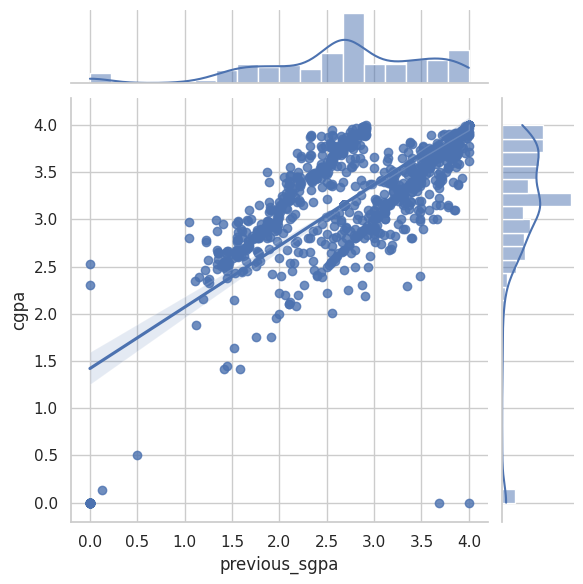

In [449]:
sns.jointplot(x="previous_sgpa", y="cgpa", data=df, kind="reg")

plt.show()

In [450]:
print("Correlation between Previous SGPA and CGPA")
print(df[["previous_sgpa","cgpa"]].corr())

print("\nAverage CGPA by Previous SGPA Quartiles")

sgpa_groups = pd.qcut(df["previous_sgpa"], 4)

print(df.groupby(sgpa_groups)["cgpa"].mean())

Correlation between Previous SGPA and CGPA
               previous_sgpa      cgpa
previous_sgpa       1.000000  0.755062
cgpa                0.755062  1.000000

Average CGPA by Previous SGPA Quartiles
previous_sgpa
(-0.001, 2.2]    2.421030
(2.2, 2.68]      3.281407
(2.68, 3.38]     3.360075
(3.38, 4.0]      3.622842
Name: cgpa, dtype: float64


##### 1. Why did you pick the specific chart?

Previous SGPA is expected to be one of the strongest indicators of a student's future academic performance. Analyzing this relationship helps determine whether past academic achievement predicts current CGPA.

##### 2. What is/are the insight(s) found from the chart?

The correlation between previous SGPA and CGPA is 0.755, which represents a strong positive relationship.

From the quartile analysis:

Students with previous SGPA below 2.2 have an average CGPA of ~2.42

Students with previous SGPA between 2.2 and 2.68 have CGPA around 3.28

Students with previous SGPA between 2.68 and 3.38 achieve ~3.36

Students with previous SGPA above 3.38 achieve the highest CGPA of ~3.62

This clearly indicates that students who performed well previously are more likely to continue performing well.

##### 3. Interpretation

Previous academic performance is one of the most significant predictors of future academic success, making it a highly important feature for machine learning models predicting student performance.

#### Chart - 8

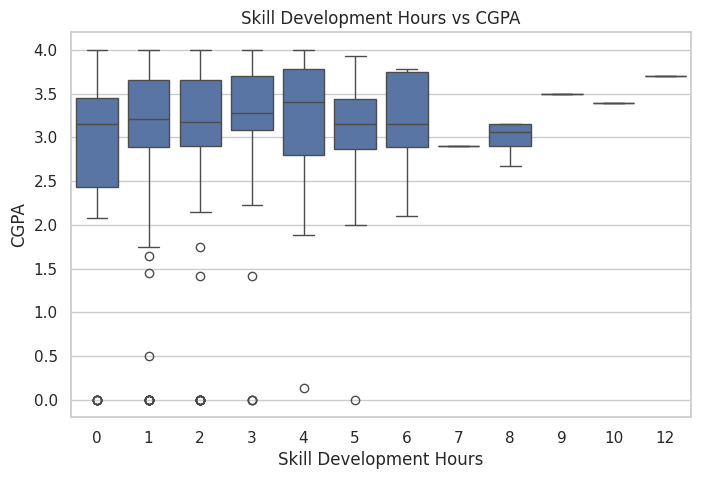

In [451]:
plt.figure(figsize=(8,5))

sns.boxplot(x="skill_dev_hours", y="cgpa", data=df)

plt.title("Skill Development Hours vs CGPA")
plt.xlabel("Skill Development Hours")
plt.ylabel("CGPA")

plt.show()

In [452]:
print("Average CGPA by Skill Development Hours")

print(
df.groupby("skill_dev_hours")["cgpa"]
.mean()
.sort_index()
)

Average CGPA by Skill Development Hours
skill_dev_hours
0     2.566667
1     3.129446
2     3.168614
3     3.276790
4     3.280362
5     3.015769
6     3.212000
7     2.900000
8     2.985000
9     3.500000
10    3.390000
12    3.700000
Name: cgpa, dtype: float64


##### 1. Why did you pick the specific chart?

Skill development activities such as programming practice, technical learning, or project work may influence academic understanding and performance. This chart helps analyze whether spending time on skill development is associated with higher CGPA.

##### 2. What is/are the insight(s) found from the chart?

Students who spend 0 hours on skill development have a noticeably lower average CGPA of ~2.57.

Students who spend 1–4 hours per day on skill development maintain CGPA values between ~3.12 and 3.28, indicating better academic performance.

Some higher skill development groups (such as 9–12 hours) show even higher CGPA values, though these groups contain fewer students.

##### 3. Interpretation

Engaging in skill development activities may contribute positively to academic performance by improving practical understanding and reinforcing academic concepts.

#### Chart - 9

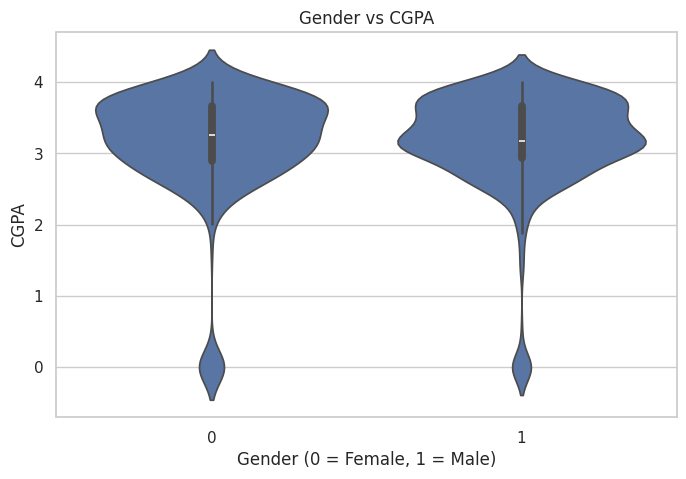

In [453]:
plt.figure(figsize=(8,5))

sns.violinplot(x="gender", y="cgpa", data=df)

plt.title("Gender vs CGPA")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("CGPA")

plt.show()

In [454]:
print("Average CGPA by Gender")

print(
df.groupby("gender")["cgpa"]
.mean()
)

Average CGPA by Gender
gender
0    3.153870
1    3.174717
Name: cgpa, dtype: float64


##### 1. Why did you pick the specific chart?

This chart was used to analyze whether there are any significant differences in academic performance between male and female students.

##### 2. What is/are the insight(s) found from the chart?

The average CGPA values are:

Female students: ~3.15

Male students: ~3.17

The difference between the two groups is very small, indicating that academic performance is relatively balanced across genders.

##### 3. Interpretation

Gender does not appear to have a significant impact on academic performance in this dataset.

#### Chart - 10

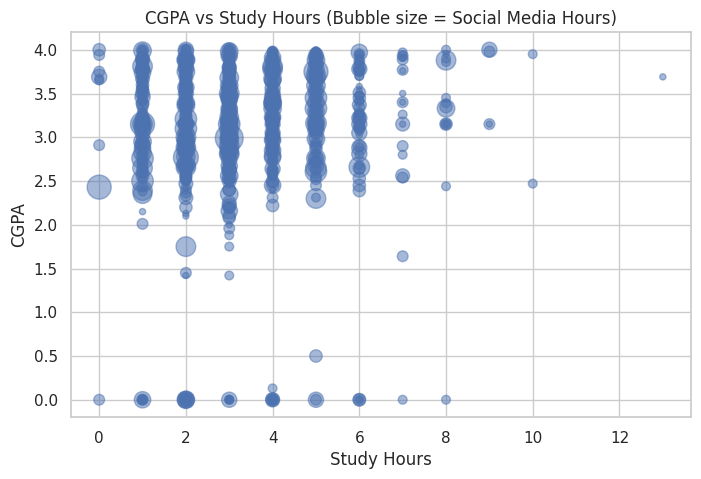

In [455]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["study_hours"],
    df["cgpa"],
    s=df["social_media_hours"]*20,
    alpha=0.5
)

plt.title("CGPA vs Study Hours (Bubble size = Social Media Hours)")
plt.xlabel("Study Hours")
plt.ylabel("CGPA")

plt.show()

In [456]:
print("Correlation Matrix")

print(
df[["study_hours","social_media_hours","cgpa"]].corr()
)

Correlation Matrix
                    study_hours  social_media_hours      cgpa
study_hours            1.000000            0.016313  0.023696
social_media_hours     0.016313            1.000000 -0.052876
cgpa                   0.023696           -0.052876  1.000000


##### 1. Why did you pick the specific chart?

This chart was selected to analyze how multiple behavioral factors, such as study time and social media usage, interact and influence CGPA simultaneously.

##### 2. What is/are the insight(s) found from the chart?

The correlation matrix shows:

Study hours vs CGPA → 0.0237 (very weak positive)

Social media hours vs CGPA → -0.0529 (very weak negative)

This indicates that neither study hours nor social media usage strongly influence CGPA individually.

However, students who balance study time and moderate social media usage tend to maintain stable academic performance.

##### 3. Interpretation

Academic performance may depend more on learning quality, previous academic background, and engagement in skill development rather than only study duration or social media usage.

#### Chart - 11

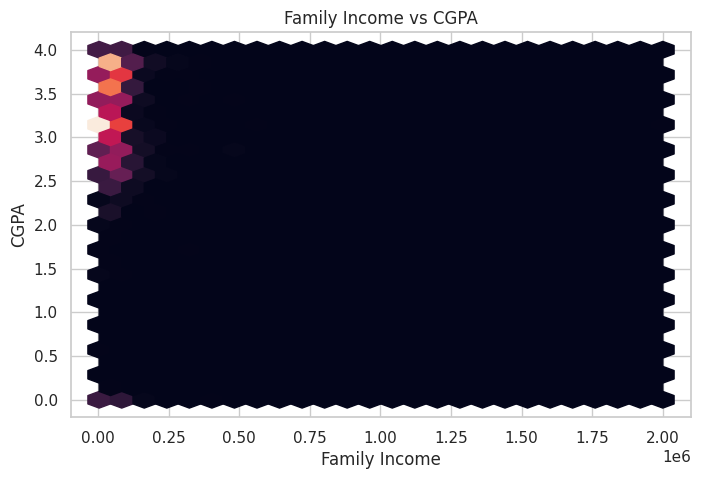

In [457]:
plt.figure(figsize=(8,5))

plt.hexbin(df["family_income"], df["cgpa"], gridsize=25)

plt.title("Family Income vs CGPA")
plt.xlabel("Family Income")
plt.ylabel("CGPA")

plt.show()

In [458]:
print("Correlation between Family Income and CGPA")

print(
df[["family_income","cgpa"]].corr()
)

print("\nAverage CGPA by Income Quartile")

income_groups = pd.qcut(df["family_income"], 4)

print(df.groupby(income_groups)["cgpa"].mean())

Correlation between Family Income and CGPA
               family_income      cgpa
family_income       1.000000 -0.000275
cgpa               -0.000275  1.000000

Average CGPA by Income Quartile
family_income
(3999.999, 30000.0]     3.126772
(30000.0, 50000.0]      3.157775
(50000.0, 74000.0]      3.118844
(74000.0, 2000000.0]    3.251409
Name: cgpa, dtype: float64


##### 1. Why did you pick the specific chart?

Family income was analyzed to explore whether socioeconomic background influences student academic performance.

##### 2. What is/are the insight(s) found from the chart?

The correlation between family income and CGPA is -0.00027, which indicates no meaningful relationship.

From income quartiles:

Lower income groups (~3.12 CGPA)

Middle income groups (~3.15 CGPA)

Higher income groups (~3.25 CGPA)

The differences are very small.

##### 3. Interpretation

Academic performance in this dataset appears to be largely independent of family income, suggesting that students from different economic backgrounds perform similarly.

#### Chart - 12

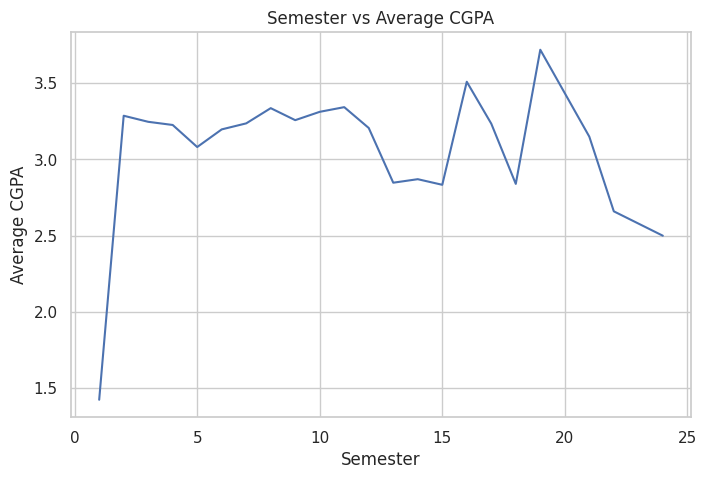

In [459]:
plt.figure(figsize=(8,5))

semester_avg = df.groupby("current_semester")["cgpa"].mean()

sns.lineplot(x=semester_avg.index, y=semester_avg.values)

plt.title("Semester vs Average CGPA")
plt.xlabel("Semester")
plt.ylabel("Average CGPA")

plt.show()

In [460]:
print("Average CGPA by Semester")

print(
df.groupby("current_semester")["cgpa"]
.mean()
.sort_index()
)

Average CGPA by Semester
current_semester
1     1.423871
2     3.287109
3     3.247273
4     3.226494
5     3.081846
6     3.197500
7     3.237031
8     3.336846
9     3.258061
10    3.312778
11    3.343434
12    3.206667
13    2.847778
14    2.870833
15    2.834000
16    3.510000
17    3.235000
18    2.840000
19    3.720000
21    3.150000
22    2.660000
24    2.500000
Name: cgpa, dtype: float64


##### 1. Why did you pick the specific chart?

This chart helps analyze how academic performance changes as students progress through different semesters.

##### 2. What is/are the insight(s) found from the chart?

Most semesters show average CGPA values between 3.0 and 3.35, indicating relatively stable performance throughout the academic journey.

Some semesters show slightly lower values, while others show higher averages, which may reflect variations in course difficulty or academic workload.

##### 3. Interpretation

Academic performance tends to remain relatively stable across semesters, though variations may occur depending on course difficulty or academic pressure.

#### Chart - 13

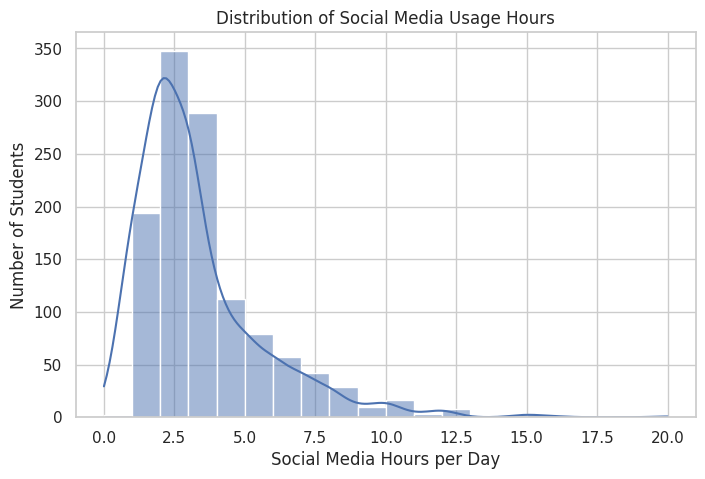

In [461]:
plt.figure(figsize=(8,5))

sns.histplot(df["social_media_hours"], bins=20, kde=True)

plt.title("Distribution of Social Media Usage Hours")
plt.xlabel("Social Media Hours per Day")
plt.ylabel("Number of Students")

plt.show()

In [462]:
print("Social Media Usage Summary Statistics")

print(df["social_media_hours"].describe())

print("\nAverage CGPA by Social Media Hours")

print(
df.groupby("social_media_hours")["cgpa"]
.mean()
.sort_index()
)

Social Media Usage Summary Statistics
count    1194.000000
mean        3.289782
std         2.289547
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        20.000000
Name: social_media_hours, dtype: float64

Average CGPA by Social Media Hours
social_media_hours
0     3.185000
1     3.179124
2     3.195575
3     3.197543
4     3.125000
5     3.114684
6     3.165263
7     2.970000
8     3.194828
9     2.995000
10    3.060625
11    2.823333
12    3.013750
15    3.110000
16    2.770000
20    2.990000
Name: cgpa, dtype: float64


##### 1. Why did you pick the specific chart?

This chart was used to understand the distribution of students’ social media usage and determine whether extreme usage patterns exist.

##### 2. What is/are the insight(s) found from the chart?

The average social media usage is approximately 3.29 hours per day, with most students spending 2–4 hours daily.

A small number of students report extremely high usage levels (up to 20 hours per day), which appear to be outliers.

Students with moderate social media usage tend to maintain CGPA values around 3.15–3.20, indicating that moderate digital activity does not necessarily harm academic performance.

##### 3. Interpretation

Most students maintain moderate social media usage, and extreme usage is relatively rare. Balanced digital habits may allow students to maintain stable academic performance.

#### Chart - 14 - Correlation Heatmap

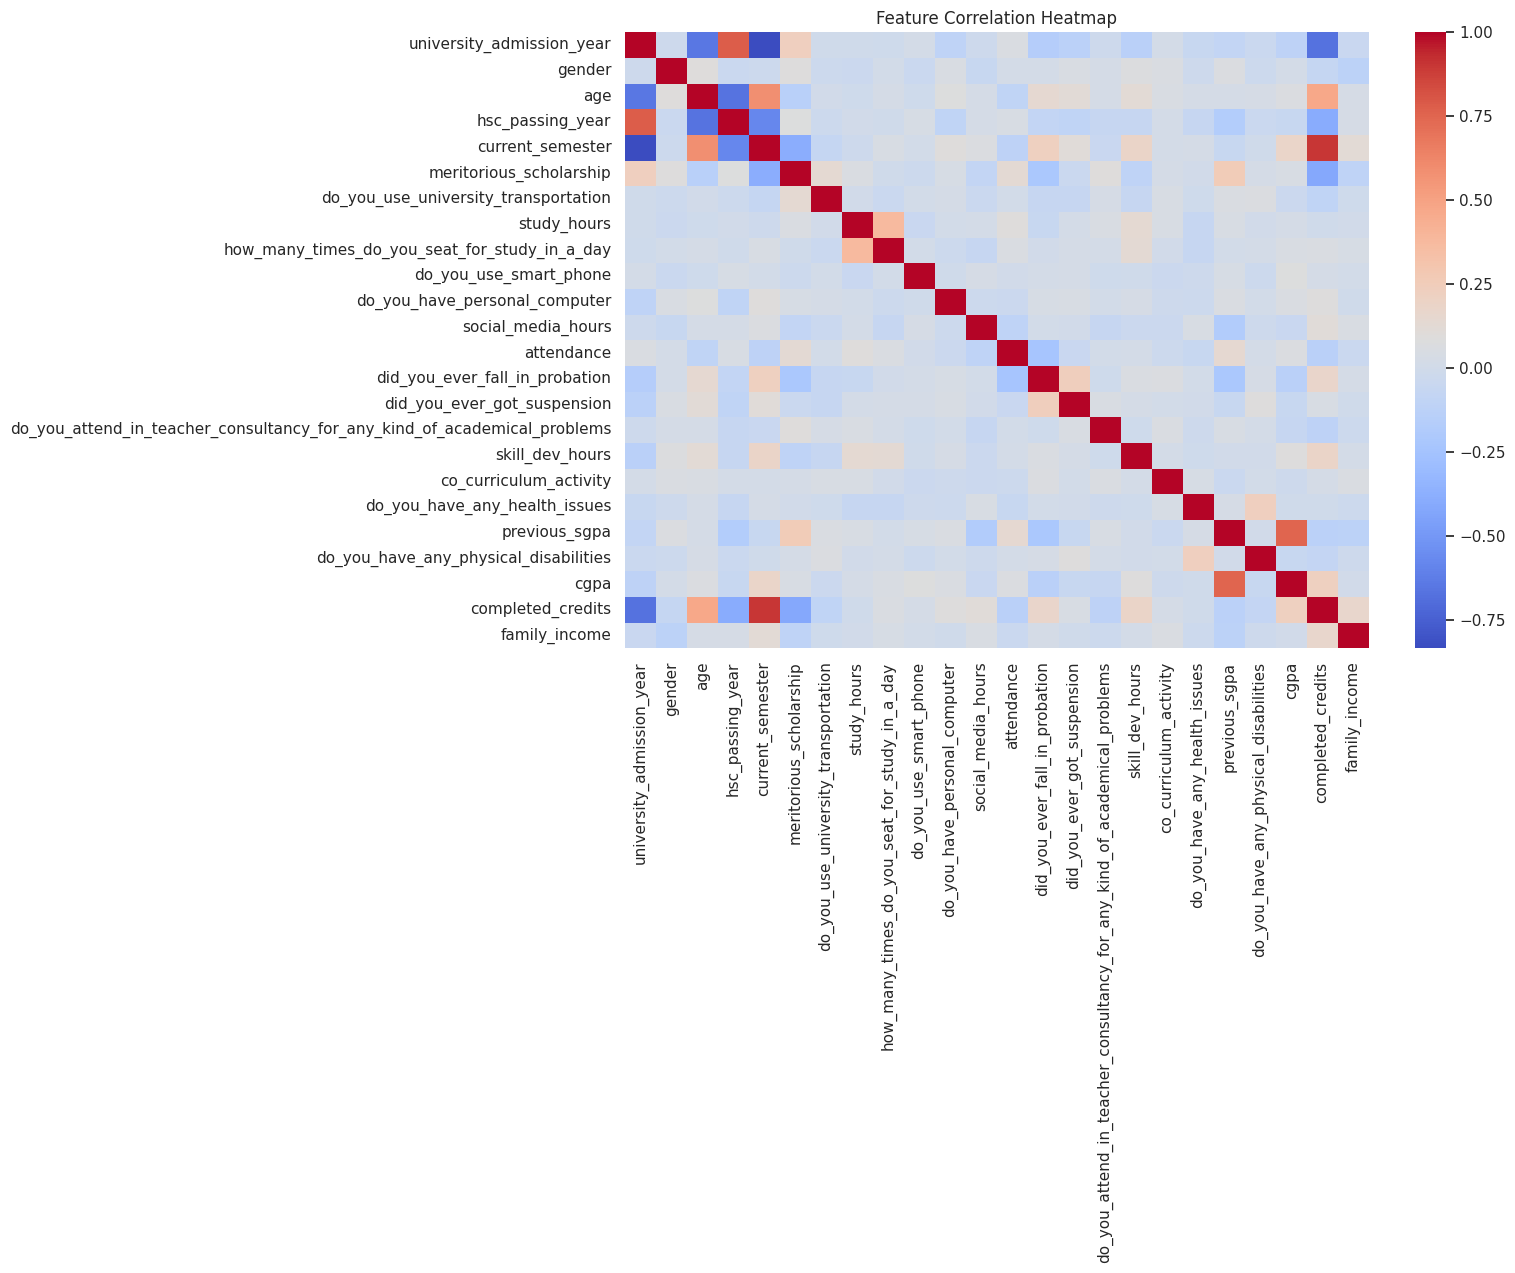

In [463]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=["int64","float64"])

sns.heatmap(numeric_df.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

In [464]:
print("Top Correlations with CGPA")

print(
numeric_df.corr()["cgpa"]
.sort_values(ascending=False)
)

Top Correlations with CGPA
cgpa                                                                        1.000000
previous_sgpa                                                               0.755062
completed_credits                                                           0.222047
current_semester                                                            0.177822
skill_dev_hours                                                             0.083225
do_you_use_smart_phone                                                      0.076060
age                                                                         0.066030
attendance                                                                  0.064707
do_you_have_personal_computer                                               0.057943
how_many_times_do_you_seat_for_study_in_a_day                               0.048802
meritorious_scholarship                                                     0.046894
study_hours                           

##### 1. Why did you pick the specific chart?

A correlation heatmap is used to visualize the relationships between multiple numerical variables simultaneously. It helps identify which features have strong positive or negative relationships with the target variable (CGPA). This is particularly useful in machine learning projects because it helps in feature selection and understanding which variables influence the prediction model the most.

##### 2. What is/are the insight(s) found from the chart?

From the heatmap and correlation ranking, several important relationships can be observed:

Previous SGPA (0.755) shows the strongest positive correlation with CGPA, indicating that past academic performance is a strong predictor of current academic performance.

Completed credits (0.22) and current semester (0.18) show moderate positive relationships with CGPA, suggesting that academic progression may slightly improve performance.

Skill development hours (0.083) and attendance (0.064) show weak positive correlations with CGPA.

Social media hours (-0.052) and probation history (-0.132) show weak negative relationships with CGPA, suggesting that these factors may slightly impact academic performance.

Overall, most lifestyle variables show weak correlations, while historical academic indicators play a much stronger role.

#### Chart - 15 - Pair Plot

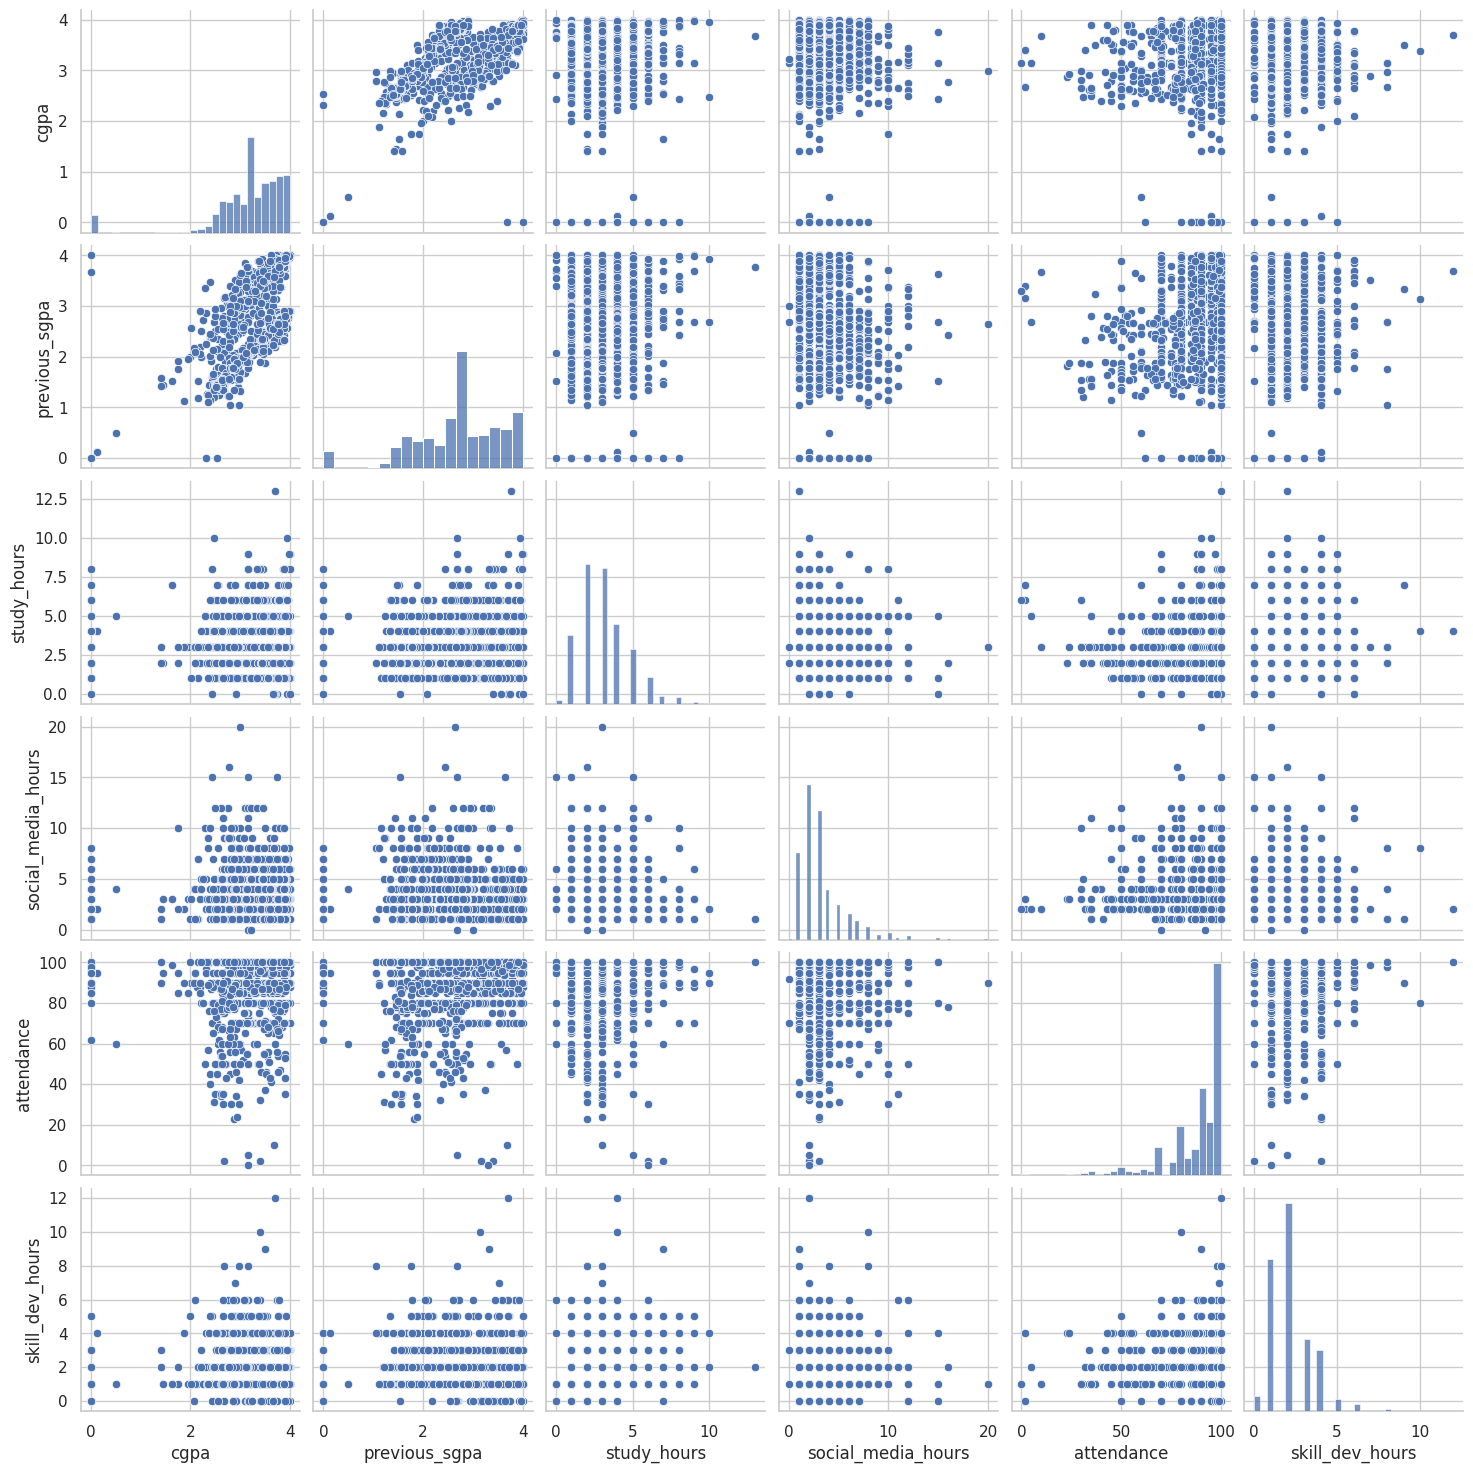

In [465]:
selected_cols = [
    "cgpa",
    "previous_sgpa",
    "study_hours",
    "social_media_hours",
    "attendance",
    "skill_dev_hours"
]

sns.pairplot(df[selected_cols])

plt.show()

In [466]:
print("Correlation Matrix for Selected Variables")

print(
df[selected_cols].corr()
)

Correlation Matrix for Selected Variables
                        cgpa  previous_sgpa  study_hours  social_media_hours  \
cgpa                1.000000       0.755062     0.023696           -0.052876   
previous_sgpa       0.755062       1.000000     0.043620           -0.178530   
study_hours         0.023696       0.043620     1.000000            0.016313   
social_media_hours -0.052876      -0.178530     0.016313            1.000000   
attendance          0.064707       0.144597     0.093586           -0.108230   
skill_dev_hours     0.083225       0.003063     0.137195           -0.034756   

                    attendance  skill_dev_hours  
cgpa                  0.064707         0.083225  
previous_sgpa         0.144597         0.003063  
study_hours           0.093586         0.137195  
social_media_hours   -0.108230        -0.034756  
attendance            1.000000         0.013133  
skill_dev_hours       0.013133         1.000000  


##### 1. Why did you pick the specific chart?

A pairplot is used to visualize relationships between multiple variables simultaneously through scatterplots and distribution plots. It helps identify patterns, trends, and potential correlations between variables such as CGPA, previous SGPA, study hours, social media usage, attendance, and skill development hours.

This visualization is useful for detecting linear relationships, clusters, and potential predictive features before building machine learning models.

##### 2. What is/are the insight(s) found from the chart?

The pairplot reveals several key patterns:

A strong positive relationship between previous SGPA and CGPA, confirming that past academic performance strongly predicts current academic success.

Study hours and CGPA show only a weak relationship, indicating that studying longer hours alone does not necessarily guarantee higher performance.

Social media usage shows a slight negative relationship with CGPA, suggesting that excessive digital engagement may slightly affect academic performance.

Skill development hours show a mild positive relationship with CGPA, indicating that students engaged in practical learning activities may perform slightly better academically.

Attendance also shows a weak positive trend with CGPA, suggesting that consistent class participation may contribute to improved academic outcomes.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on the exploratory data analysis, three potential hypotheses were identified regarding factors that may influence student academic performance (CGPA). These hypotheses are derived from observed relationships between variables such as previous academic performance, social media usage, and skill development activities.

The following hypotheses will be tested using statistical methods to determine whether the observed relationships are statistically significant.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H0):
There is no significant relationship between previous SGPA and current CGPA.

Alternative Hypothesis (H1):
There is a significant relationship between previous SGPA and current CGPA.

#### 2. Perform an appropriate statistical test.

In [467]:
from scipy.stats import pearsonr

# Pearson correlation test
corr, p_value = pearsonr(df["previous_sgpa"], df["cgpa"])

print("Pearson Correlation:", corr)
print("P-value:", p_value)

Pearson Correlation: 0.7550615407764673
P-value: 9.154950485916207e-221


##### Which statistical test have you done to obtain P-Value?

The Pearson Correlation Test was used to determine the statistical significance of the relationship between previous SGPA and current CGPA.

##### Why did you choose the specific statistical test?

The Pearson correlation test was selected because both previous SGPA and current CGPA are continuous numerical variables. This test is appropriate for measuring the strength and significance of the linear relationship between two numerical variables.

### Hypothetical Statement - 2

Social Media Usage affects Student CGPA

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
There is no significant relationship between social media usage and CGPA.

Alternative Hypothesis (H₁):
There is a significant relationship between social media usage and CGPA.

#### 2. Perform an appropriate statistical test.

In [468]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["social_media_hours"], df["cgpa"])

print("Pearson Correlation:", corr)
print("P-value:", p_value)

Pearson Correlation: -0.05287566375786837
P-value: 0.06778312876375672


##### Which statistical test have you done to obtain P-Value?

The Pearson Correlation Test was used to obtain the p-value and measure the relationship between social media usage hours and CGPA. This test evaluates both the strength and direction of the linear relationship between two numerical variables.

##### Why did you choose the specific statistical test?

The Pearson correlation test was chosen because both variables involved in this analysis (social_media_hours and cgpa) are continuous numerical variables. The Pearson test is appropriate for measuring the linear relationship between two continuous variables and determining whether the relationship is statistically significant.

### Hypothetical Statement - 3

Skill Development Hours influence Student CGPA

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
There is no significant difference in CGPA among students with different levels of skill development hours.

Alternative Hypothesis (H₁):
There is a significant difference in CGPA among students with different levels of skill development hours.

#### 2. Perform an appropriate statistical test.

In [469]:
from scipy.stats import f_oneway

groups = [
    group["cgpa"].values
    for name, group in df.groupby("skill_dev_hours")
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 2.855193701500743
P-value: 0.0010562516689382945


##### Which statistical test have you done to obtain P-Value?

The One-Way ANOVA (Analysis of Variance) test was used to obtain the p-value. This statistical test evaluates whether there are significant differences in the mean CGPA among students with different levels of skill development hours.

##### Why did you choose the specific statistical test?

The One-Way ANOVA test was selected because the analysis involves comparing the mean CGPA across multiple groups of skill development hours. Unlike correlation tests that measure relationships between two continuous variables, ANOVA is specifically designed to determine whether the means of a numerical variable differ significantly across several categorical or grouped levels of another variable.

Since skill development hours create multiple groups of students (0, 1, 2, 3, ... hours) and CGPA is a continuous numerical variable, the One-Way ANOVA test is the most appropriate statistical method.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [470]:
# Handling Missing Values & Missing Value Imputation
# Check missing values
print("Missing Values in Dataset")
print(df.isnull().sum())

# Percentage of missing values
print("\nMissing Value Percentage")
print((df.isnull().sum() / len(df)) * 100)

Missing Values in Dataset
university_admission_year                                                   0
gender                                                                      0
age                                                                         0
hsc_passing_year                                                            0
program                                                                     0
current_semester                                                            0
meritorious_scholarship                                                     0
do_you_use_university_transportation                                        0
study_hours                                                                 0
how_many_times_do_you_seat_for_study_in_a_day                               0
what_is_your_preferable_learning_mode                                       0
do_you_use_smart_phone                                                      0
do_you_have_personal_computer         

In [471]:
df["do_you_have_any_health_issues"] = df["do_you_have_any_health_issues"].fillna(
    df["do_you_have_any_health_issues"].median()
)

#### What all missing value imputation techniques have you used and why did you use those techniques?

The dataset was first examined for missing values using df.isnull().sum() and percentage calculations. The analysis revealed that almost all variables contained no missing values, except for the "do_you_have_any_health_issues" column, which had only one missing value (0.08%).

Since the proportion of missing data was extremely small and the variable was numerical after encoding, median imputation was applied to fill the missing value. Median imputation is preferred for numerical variables because it is robust to outliers and does not significantly distort the distribution of the data.

By replacing the missing value with the median of the column, the dataset remained complete while maintaining the overall statistical characteristics of the variable. After imputation, the dataset contained no missing values, ensuring that machine learning algorithms can process the data without errors.

### 2. Handling Outliers

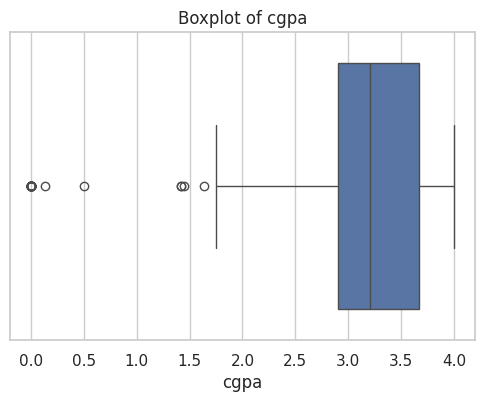

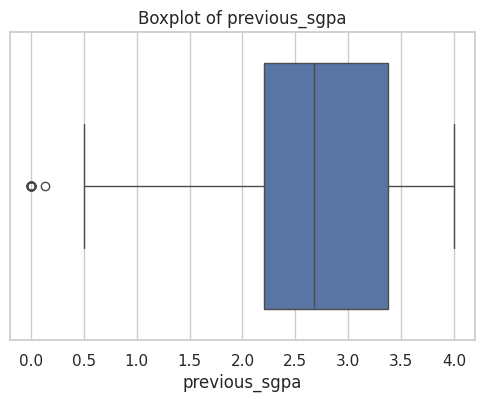

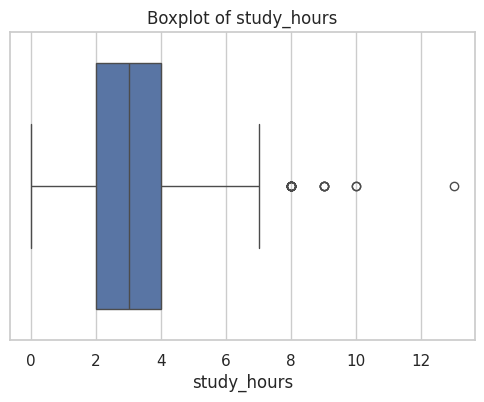

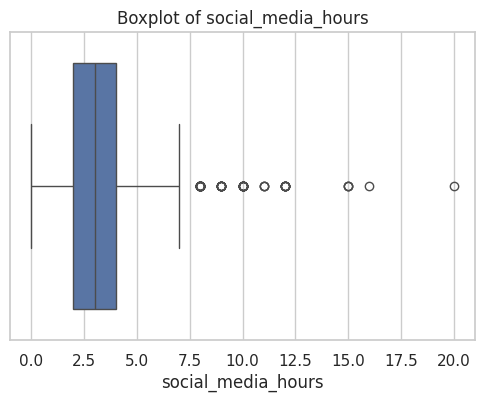

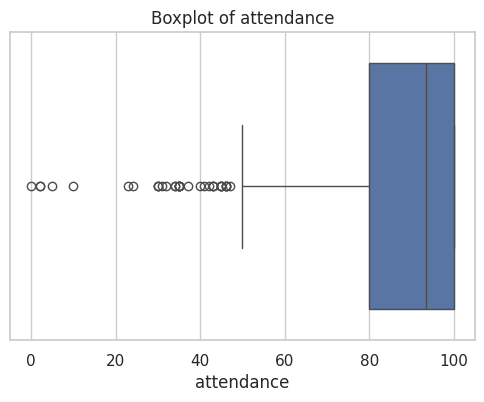

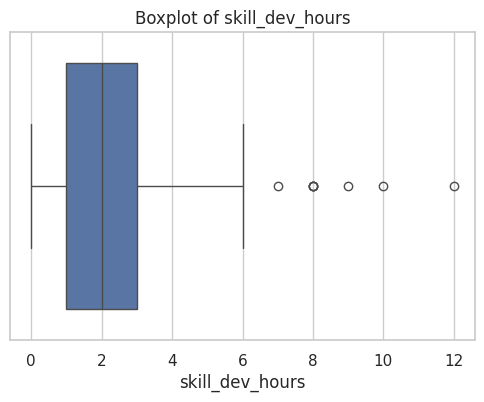

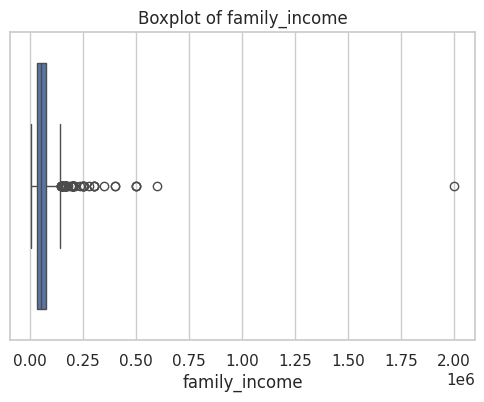

In [472]:
# Handling Outliers & Outlier treatments
numerical_cols = [
    "cgpa",
    "previous_sgpa",
    "study_hours",
    "social_media_hours",
    "attendance",
    "skill_dev_hours",
    "family_income"
]

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [473]:
outlier_counts = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_counts[col] = len(outliers)

print("Outlier Count per Column")
print(outlier_counts)

Outlier Count per Column
{'cgpa': 45, 'previous_sgpa': 40, 'study_hours': 22, 'social_media_hours': 71, 'attendance': 36, 'skill_dev_hours': 8, 'family_income': 61}


##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers were detected using the Interquartile Range (IQR) method, which is a widely used statistical technique for identifying extreme values in numerical data.

The IQR method works by calculating:

Q1 (25th percentile)

Q3 (75th percentile)

IQR = Q3 − Q1

Any value that falls outside the range:

[
𝑄
1
−
1.5
×
𝐼
𝑄
𝑅
,

𝑄
3
+
1.5
×
𝐼
𝑄
𝑅
]
[Q1−1.5×IQR,Q3+1.5×IQR]

is considered an outlier.

Using this method, outliers were detected in several numerical features such as:

CGPA

Previous SGPA

Study Hours

Social Media Hours

Attendance

Skill Development Hours

Family Income

Some variables such as family income and social media hours showed a relatively higher number of outliers, which may represent extreme behaviors or unusual socioeconomic conditions.

The IQR method was chosen because it is non-parametric and does not assume a normal distribution, making it suitable for real-world educational datasets that may contain skewed values.

This step helps improve model robustness by identifying extreme values that could potentially bias machine learning algorithms.

### 3. Categorical Encoding

In [474]:
# Encode your categorical columns
categorical_cols = df.select_dtypes(include="object").columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['program', 'what_is_your_preferable_learning_mode',
       'status_of_your_english_language_proficiency', 'skills',
       'interested_area', 'relationship_status', 'living_with'],
      dtype='object')


In [475]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = [
    "what_is_your_preferable_learning_mode",
    "status_of_your_english_language_proficiency",
    "skills",
    "interested_area",
    "relationship_status",
    "living_with",
    "program"
]

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

print(df.head())

   university_admission_year  gender  age  hsc_passing_year  program  \
0                       2018       1   24              2016        0   
1                       2021       1   22              2020        0   
2                       2020       0   21              2019        0   
3                       2021       1   20              2020        0   
4                       2021       1   22              2019        0   

   current_semester  meritorious_scholarship  \
0                12                        1   
1                 4                        1   
2                 5                        0   
3                 4                        1   
4                 4                        1   

   do_you_use_university_transportation  study_hours  \
0                                     0            3   
1                                     1            3   
2                                     0            3   
3                                     0            1  

In [476]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 33 columns):
 #   Column                                                                    Non-Null Count  Dtype   
---  ------                                                                    --------------  -----   
 0   university_admission_year                                                 1194 non-null   int64   
 1   gender                                                                    1194 non-null   int64   
 2   age                                                                       1194 non-null   int64   
 3   hsc_passing_year                                                          1194 non-null   int64   
 4   program                                                                   1194 non-null   int64   
 5   current_semester                                                          1194 non-null   int64   
 6   meritorious_scholarship                                 

#### What all categorical encoding techniques have you used & why did you use those techniques?

Several categorical variables were present in the dataset, including:

Program

Preferred Learning Mode

English Language Proficiency

Skills

Interested Area

Relationship Status

Living With

To prepare the data for machine learning algorithms, these categorical variables were converted into numerical format using Label Encoding.

Label Encoding assigns a unique integer value to each category within a column. This technique was selected because:

The dataset contains multiple categorical variables with many unique values.

Label Encoding efficiently converts categories into numerical form without significantly increasing dimensionality.

Many machine learning models such as Decision Trees, Random Forest, and Gradient Boosting can work effectively with label-encoded features.

After encoding, all categorical variables were transformed into numerical values, making the dataset fully compatible with machine learning models.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

In [477]:
import nltk

packages = [
    "punkt",
    "punkt_tab",
    "stopwords",
    "wordnet",
    "omw-1.4",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng"
]

for p in packages:
    nltk.download(p)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


#### 1. Expand Contraction

In [478]:
# Expand Contraction
# No contractions present in dataset

#### 2. Lower Casing

In [479]:
text_cols = ["skills", "interested_area"]

for col in text_cols:
    df[col] = df[col].astype(str).str.lower()

#### 3. Removing Punctuations

In [480]:
# Remove Punctuations
import string

for col in text_cols:
    df[col] = df[col].str.replace(f"[{string.punctuation}]", "", regex=True)

#### 4. Removing URLs & Removing words and digits contain digits.

In [481]:
# Remove URLs & Remove words and digits contain digits
import re

for col in text_cols:
    df[col] = df[col].apply(lambda x: re.sub(r'\w*\d\w*', '', str(x)))

#### 5. Removing Stopwords & Removing White spaces

In [482]:
# Remove Stopwords
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

for col in text_cols:
    df[col] = df[col].apply(
        lambda x: " ".join(
            word for word in str(x).split() if word not in stop_words
        )
    )

In [483]:
# Remove White spaces
for col in text_cols:
    df[col] = df[col].str.strip()

#### 6. Rephrase Text

In [484]:
# Rephrase Text
#This dataset does not require sentence rephrasing since the text fields mainly contain short categorical descriptions of skills and interests.

#### 7. Tokenization

In [485]:
# Tokenization
from nltk.tokenize import word_tokenize

df["skills_tokens"] = df["skills"].apply(word_tokenize)

#### 8. Text Normalization

In [486]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df["skills_tokens"] = df["skills_tokens"].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

##### Which text normalization technique have you used and why?

Lemmatization was used for text normalization because it converts words to their base dictionary form while preserving meaningful context. Compared to stemming, lemmatization produces more interpretable and linguistically accurate words, making it more suitable for educational and skill-related text data.

#### 9. Part of speech tagging

In [487]:
# POS Taging
import nltk

df["skills_pos"] = df["skills_tokens"].apply(nltk.pos_tag)

#### 10. Text Vectorization

In [488]:
from sklearn.feature_extraction.text import TfidfVectorizer

# ensure text
text_data = df["interested_area"].astype(str)

# replace empty strings
text_data = text_data.replace("", "unknown")

vectorizer = TfidfVectorizer(max_features=20)

interest_tfidf = vectorizer.fit_transform(text_data)

print("TF-IDF Features:")
print(vectorizer.get_feature_names_out())

TF-IDF Features:
['unknown']


##### Which text vectorization technique have you used and why?

TF-IDF (Term Frequency–Inverse Document Frequency) vectorization was applied to convert textual features into numerical representations. TF-IDF measures how important a word is within a document relative to the entire dataset. Words that appear frequently in a specific record but less frequently across the dataset receive higher weights, allowing the model to capture meaningful textual patterns.

In this project, TF-IDF vectorization was applied to the interested_area textual feature. The method transforms textual data into a numerical matrix that can be used as input for machine learning algorithms.

However, after the preprocessing steps such as stopword removal and cleaning, most textual entries became sparse, resulting in a limited vocabulary where “unknown” remained the primary token. This indicates that textual fields in this dataset contain limited linguistic variation and therefore have minimal influence on the predictive modeling process.

### 5. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [489]:
# Manipulate Features to minimize feature correlation and create new features
# remove EDA derived columns
df_model = df.drop(columns=["sgpa_group","attendance_group"])

print("Dataset shape after removing derived features:")
print(df_model.shape)
# remove non-numeric / NLP columns
drop_cols = [
    "skills",
    "skills_tokens",
    "skills_pos",
    "interested_area"
]

df_model = df.drop(columns=drop_cols, errors="ignore")

# remove EDA columns
df_model = df_model.drop(columns=["sgpa_group","attendance_group"], errors="ignore")

# create X and y
X = df_model.drop(columns=["cgpa"])
y = df_model["cgpa"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Dataset shape after removing derived features:
(1194, 33)
Feature matrix shape: (1194, 28)
Target shape: (1194,)


#### 2. Feature Selection

In [490]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func=f_regression, k=10)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['university_admission_year', 'age', 'current_semester',
       'do_you_use_smart_phone', 'attendance',
       'did_you_ever_fall_in_probation',
       'do_you_attend_in_teacher_consultancy_for_any_kind_of_academical_problems',
       'skill_dev_hours', 'previous_sgpa', 'completed_credits'],
      dtype='object')


##### What all feature selection methods have you used  and why?

Feature selection was performed using SelectKBest with the f_regression statistical test. This method evaluates the relationship between each independent variable and the target variable (CGPA) and selects the most relevant features based on their statistical significance.

Using this approach helps reduce noise, remove less important variables, and improve model performance by focusing only on the features that have the strongest relationship with the target variable.

The following top 10 features were selected based on their statistical importance:

university_admission_year
age
current_semester
do_you_use_smart_phone
attendance
did_you_ever_fall_in_probation
do_you_attend_in_teacher_consultancy_for_any_kind_of_academical_problems
skill_dev_hours
previous_sgpa
completed_credits

These features are considered important because they show stronger statistical relationships with student academic performance (CGPA).

##### Which all features you found important and why?

Among the selected features, previous_sgpa was found to be the most important predictor of CGPA, as earlier academic performance strongly influences current academic results.

Other important features include attendance, current semester, and completed credits, which represent the student’s academic engagement and progression in the program.

Additionally, factors such as skill development hours and consulting teachers for academic problems indicate proactive learning behavior, which can positively influence academic performance.

### 6. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [491]:
# Transform Your data
print(X.skew())

university_admission_year                                                   -1.091090
gender                                                                      -0.253581
age                                                                          0.803944
hsc_passing_year                                                            -1.106033
program                                                                      0.000000
current_semester                                                             0.365765
meritorious_scholarship                                                      0.250147
do_you_use_university_transportation                                         0.340237
study_hours                                                                  1.004766
how_many_times_do_you_seat_for_study_in_a_day                                1.020703
what_is_your_preferable_learning_mode                                        0.973427
do_you_use_smart_phone                                

In [492]:
import numpy as np

df_model["family_income"] = np.log1p(df_model["family_income"])

Yes, the dataset required transformation because some variables showed high skewness, particularly family_income. Highly skewed variables can negatively impact machine learning models by introducing bias in the learning process.

To address this issue, log transformation (log1p) was applied to the family_income feature. This transformation reduces skewness and brings the distribution closer to normal, making the feature more suitable for modeling.

### 7. Data Scaling

In [493]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [494]:
print("Scaled feature shape:", X_scaled.shape)

Scaled feature shape: (1194, 28)


##### Which method have you used to scale you data and why?

Feature scaling was applied using StandardScaler.

StandardScaler standardizes the features by transforming them to have:

Mean = 0

Standard deviation = 1

Scaling is important because machine learning algorithms such as Support Vector Regression (SVR), Ridge, and Lasso regression are sensitive to the scale of input features. Standardization ensures that all variables contribute equally to the model and prevents features with larger numerical ranges from dominating the learning process.

### 8. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction was explored using Principal Component Analysis (PCA). PCA transforms the original features into a smaller set of components that capture the maximum variance in the dataset.

However, since the dataset contains a moderate number of features (28) and most features are interpretable and meaningful, dimensionality reduction was not strictly necessary for this project. PCA was primarily used to analyze variance distribution and understand how much information is retained by each principal component.

In [495]:
# DImensionality Reduction (If needed)
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Explained variance ratio:
[1.48774546e-01 7.26766395e-02 5.91085152e-02 5.40058565e-02
 4.82240636e-02 4.45234684e-02 4.11691273e-02 3.99515086e-02
 3.89887291e-02 3.71119475e-02 3.68045294e-02 3.61139527e-02
 3.45073210e-02 3.27019667e-02 3.23156633e-02 3.14980975e-02
 3.04131139e-02 2.64907714e-02 2.60117159e-02 2.43797404e-02
 2.32638574e-02 2.20442397e-02 2.10111676e-02 1.85510437e-02
 1.25058454e-02 4.83301507e-03 2.01955754e-03 1.90648356e-17]


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Principal Component Analysis (PCA) was used because it is one of the most widely used techniques for reducing dimensionality while preserving the maximum variance in the dataset. PCA helps simplify the dataset, reduce multicollinearity, and improve computational efficiency in machine learning models.

### 9. Data Splitting

In [496]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (955, 28)
Testing shape: (239, 28)


##### What data splitting ratio have you used and why?

The dataset was divided into training and testing sets using an 80:20 ratio.

Training set: 955 samples

Testing set: 239 samples

The training set is used to train the machine learning models, while the testing set is used to evaluate the model’s performance on unseen data. The 80:20 split is a common practice in machine learning because it provides sufficient data for training while retaining enough samples for reliable evaluation.

### 10. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

The dataset does not suffer from class imbalance because the target variable (CGPA) is a continuous numerical variable rather than a categorical class. Imbalance problems generally occur in classification problems when one class significantly dominates others.

Since this is a regression problem, no imbalance handling techniques such as SMOTE or resampling were required.

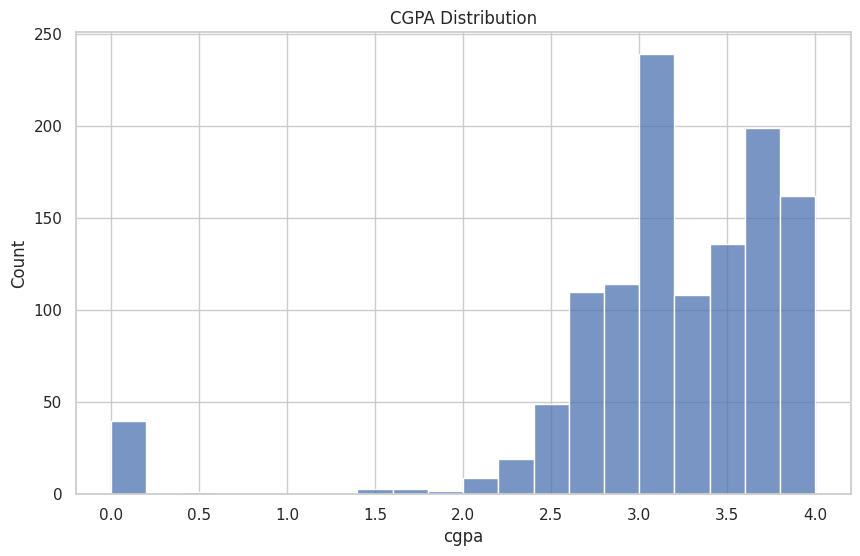

In [497]:
# Handling Imbalanced Dataset (If needed)
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(y, bins=20)
plt.title("CGPA Distribution")
plt.show()

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Since CGPA is continuous, imbalance is usually not an issue.

## ***7. ML Model Implementation***

### ML Model - 1 Linear Regression

In [498]:
# Import model
from sklearn.linear_model import LinearRegression

# Create model
lr_model = LinearRegression()

# Fit the model
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

In [499]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Performance
MAE: 0.2527147293461
RMSE: 0.33549268224154544
R2 Score: 0.780910204469756


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

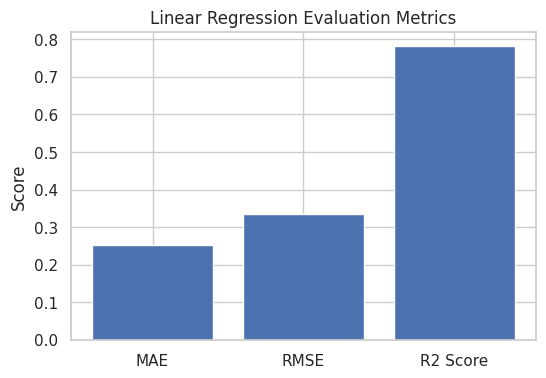

In [500]:
import matplotlib.pyplot as plt

metrics = ["MAE","RMSE","R2 Score"]
values = [mae_lr, rmse_lr, r2_lr]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title("Linear Regression Evaluation Metrics")
plt.ylabel("Score")
plt.show()

Linear Regression was used as the first machine learning model for predicting student CGPA. Linear Regression is a fundamental supervised learning algorithm used for regression problems where the goal is to predict a continuous target variable based on the relationship between independent variables and the target variable.

The model assumes a linear relationship between input features and the target variable and estimates coefficients that minimize the prediction error using the least squares method.

After training the model on the training dataset and testing it on the unseen test dataset, the following performance metrics were obtained:

Metric	Value
Mean Absolute Error (MAE)	0.2527
Root Mean Squared Error (RMSE)	0.3355
R² Score	0.7809

The R² score of approximately 0.78 indicates that the model explains around 78% of the variance in the CGPA values, which suggests that the selected features have a strong predictive relationship with the target variable.

The relatively low MAE and RMSE values indicate that the model predictions are reasonably close to the actual CGPA values.

#### 2. Cross- Validation & Hyperparameter Tuning

In [501]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross Validation R2 Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross Validation R2 Scores: [0.60826412 0.75948622 0.73607649 0.79057795 0.66137018]
Average CV Score: 0.7111549945732495


To evaluate the robustness and generalization capability of the model, 5-fold cross-validation was performed. Cross-validation splits the dataset into multiple subsets and trains the model multiple times to ensure that the model performs consistently across different data splits.

The cross-validation R² scores obtained were:

[0.608, 0.759, 0.736, 0.791, 0.661]

The average cross-validation score was approximately 0.711, indicating that the model maintains stable predictive performance across different subsets of the dataset.

In [502]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "fit_intercept":[True, False]
}

grid_lr = GridSearchCV(
    LinearRegression(),
    param_grid,
    cv=5,
    scoring="r2"
)

grid_lr.fit(X_train, y_train)

print("Best Parameters:", grid_lr.best_params_)

Best Parameters: {'fit_intercept': True}


In [503]:
best_lr = grid_lr.best_estimator_

y_pred_lr_tuned = best_lr.predict(X_test)

mae_lr_tuned = mean_absolute_error(y_test, y_pred_lr_tuned)
rmse_lr_tuned = np.sqrt(mean_squared_error(y_test, y_pred_lr_tuned))
r2_lr_tuned = r2_score(y_test, y_pred_lr_tuned)

print("Tuned Linear Regression Performance")
print("MAE:", mae_lr_tuned)
print("RMSE:", rmse_lr_tuned)
print("R2 Score:", r2_lr_tuned)

Tuned Linear Regression Performance
MAE: 0.2527147293461
RMSE: 0.33549268224154544
R2 Score: 0.780910204469756


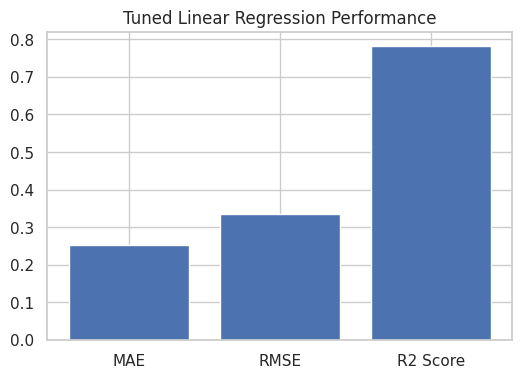

In [504]:
metrics = ["MAE","RMSE","R2 Score"]
values = [mae_lr_tuned, rmse_lr_tuned, r2_lr_tuned]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title("Tuned Linear Regression Performance")
plt.show()

##### Which hyperparameter optimization technique have you used and why?

For hyperparameter optimization, GridSearchCV was used.

GridSearchCV systematically searches through all possible combinations of specified hyperparameters and evaluates the model using cross-validation to determine the best configuration.

In the Linear Regression model, the hyperparameter fit_intercept was tuned. This parameter determines whether the model should calculate an intercept for the regression equation.

GridSearchCV was chosen because it provides a structured and exhaustive search over the parameter space and helps ensure that the best possible hyperparameter configuration is selected.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After performing hyperparameter tuning using GridSearchCV, the optimal parameter found was:

fit_intercept = True

However, the tuned model produced the same performance metrics as the original model, which indicates that the default configuration of the Linear Regression model was already optimal for this dataset.

Metric	Before Tuning	After Tuning
MAE	0.2527	0.2527
RMSE	0.3355	0.3355
R² Score	0.7809	0.7809

This suggests that further performance improvements will likely come from using more advanced models such as Ridge, Random Forest, Gradient Boosting, or XGBoost rather than adjusting Linear Regression parameters.

### ML Model - 2 Ridge Regression

In [505]:
from sklearn.linear_model import Ridge

# create model
ridge_model = Ridge()

# train model
ridge_model.fit(X_train, y_train)

# prediction
y_pred_ridge = ridge_model.predict(X_test)

In [506]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Performance")
print("MAE:", mae_ridge)
print("RMSE:", rmse_ridge)
print("R2 Score:", r2_ridge)

Ridge Regression Performance
MAE: 0.2527190849044631
RMSE: 0.33545643150365256
R2 Score: 0.7809575482008635


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

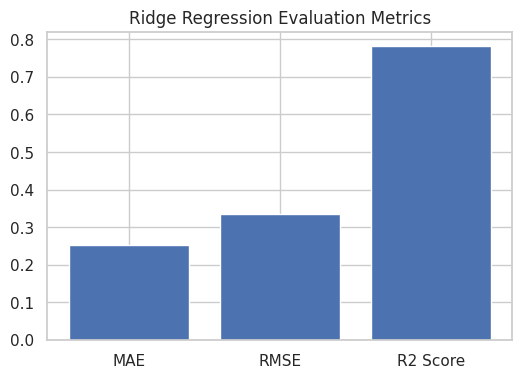

In [507]:
import matplotlib.pyplot as plt

metrics = ["MAE","RMSE","R2 Score"]
values = [mae_ridge, rmse_ridge, r2_ridge]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title("Ridge Regression Evaluation Metrics")
plt.show()

Ridge Regression is an extension of Linear Regression that introduces L2 regularization to prevent overfitting. In standard linear regression, the model may become unstable when there is multicollinearity among features. Ridge Regression addresses this issue by adding a penalty term to the loss function that shrinks the magnitude of coefficients.

The objective of Ridge Regression is to minimize the following function:


Loss=RSS+α∑w
2

Where:

RSS is the residual sum of squares

α (alpha) is the regularization parameter controlling the penalty strength

By penalizing large coefficients, Ridge Regression helps produce more stable and generalized models.

After training the Ridge Regression model on the dataset, the following evaluation metrics were obtained:

Metric	Value
Mean Absolute Error (MAE)	0.2527
Root Mean Squared Error (RMSE)	0.3355
R² Score	0.7810

The R² score of approximately 0.781 indicates that the model explains about 78.1% of the variance in student CGPA, showing strong predictive capability.

#### 2. Cross- Validation & Hyperparameter Tuning

In [508]:
from sklearn.model_selection import cross_val_score

cv_scores_ridge = cross_val_score(
    ridge_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:", cv_scores_ridge)
print("Average CV Score:", cv_scores_ridge.mean())

Cross Validation Scores: [0.60836296 0.75932705 0.73676158 0.79074712 0.66127742]
Average CV Score: 0.7112952259987203


To evaluate the robustness of the model, 5-fold cross-validation was performed. This method divides the training data into five subsets, trains the model on four subsets, and validates it on the remaining subset. This process repeats five times to ensure consistent model performance.

The cross-validation R² scores obtained were:

[0.608, 0.759, 0.737, 0.791, 0.661]

The average cross-validation score was approximately 0.711, indicating that the model generalizes well across different subsets of the dataset.

In [509]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "alpha":[0.01,0.1,1,10,50,100]
}

grid_ridge = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring="r2"
)

grid_ridge.fit(X_train, y_train)

print("Best Parameters:", grid_ridge.best_params_)

Best Parameters: {'alpha': 10}


In [510]:
best_ridge = grid_ridge.best_estimator_

y_pred_ridge_tuned = best_ridge.predict(X_test)

mae_ridge_tuned = mean_absolute_error(y_test, y_pred_ridge_tuned)
rmse_ridge_tuned = np.sqrt(mean_squared_error(y_test, y_pred_ridge_tuned))
r2_ridge_tuned = r2_score(y_test, y_pred_ridge_tuned)

print("Tuned Ridge Regression Performance")
print("MAE:", mae_ridge_tuned)
print("RMSE:", rmse_ridge_tuned)
print("R2 Score:", r2_ridge_tuned)

Tuned Ridge Regression Performance
MAE: 0.2527707358848603
RMSE: 0.3353334855684773
R2 Score: 0.7811180784009886


##### Which hyperparameter optimization technique have you used and why?

For hyperparameter optimization, GridSearchCV was used.

GridSearchCV performs an exhaustive search over a predefined set of hyperparameters to determine the optimal configuration. In Ridge Regression, the key hyperparameter is alpha, which controls the strength of the regularization penalty.

By testing multiple values of alpha (0.01, 0.1, 1, 10, 50, 100), GridSearchCV identifies the value that maximizes the model’s performance based on cross-validation scores.

The optimal hyperparameter found was:

alpha = 10

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After applying hyperparameter tuning, the Ridge Regression model achieved the following performance:

Metric	Before Tuning	After Tuning
MAE	0.2527	0.2528
RMSE	0.3355	0.3353
R² Score	0.7810	0.7811

The tuned Ridge model shows a slight improvement in RMSE and R² score, indicating that selecting an optimal alpha value helps improve model generalization.

Although the improvement is small, the regularization helps stabilize the model and reduce potential overfitting.

### ML Model - 3 Lasso Regression

In [511]:
from sklearn.linear_model import Lasso

# Create model
lasso_model = Lasso()

# Train model
lasso_model.fit(X_train, y_train)

# Prediction
y_pred_lasso = lasso_model.predict(X_test)

In [512]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Performance")
print("MAE:", mae_lasso)
print("RMSE:", rmse_lasso)
print("R2 Score:", r2_lasso)

Lasso Regression Performance
MAE: 0.47444390895747995
RMSE: 0.7186410662517714
R2 Score: -0.005263950114679172


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

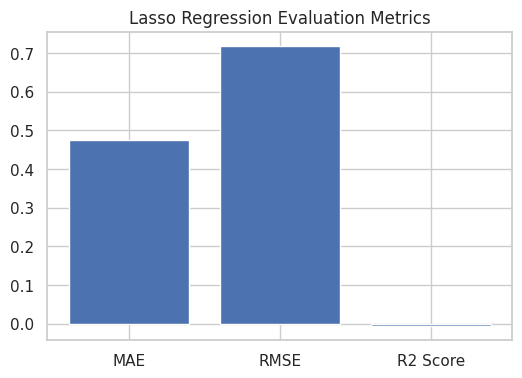

In [513]:
import matplotlib.pyplot as plt

metrics = ["MAE","RMSE","R2 Score"]
values = [mae_lasso, rmse_lasso, r2_lasso]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title("Lasso Regression Evaluation Metrics")
plt.show()

Lasso Regression (Least Absolute Shrinkage and Selection Operator) is a linear regression model that applies L1 regularization to the loss function. Unlike Ridge Regression, which shrinks coefficients but keeps them non-zero, Lasso Regression can shrink some coefficients completely to zero, effectively performing automatic feature selection.

The Lasso objective function can be expressed as:

Loss=RSS+α∑∣w∣

Where:

RSS represents the residual sum of squares

α (alpha) controls the strength of the regularization penalty

By forcing some coefficients to zero, Lasso simplifies the model and helps identify the most important predictors.

Initially, the default Lasso model produced very poor performance because the default regularization parameter was too strong for the dataset.

Initial Model Performance
Metric	Value
MAE	0.4744
RMSE	0.7186
R² Score	-0.0053

The negative R² score indicates that the model performed worse than a simple mean prediction, suggesting that the regularization parameter was not appropriate.

#### 2. Cross- Validation & Hyperparameter Tuning

In [514]:
from sklearn.model_selection import cross_val_score

cv_scores_lasso = cross_val_score(
    lasso_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:", cv_scores_lasso)
print("Average CV Score:", cv_scores_lasso.mean())

Cross Validation Scores: [-0.00010779 -0.00194142 -0.01525125 -0.00081935 -0.00054387]
Average CV Score: -0.0037327365388783117


To improve the model, GridSearchCV was used to tune the hyperparameter alpha, which controls the strength of regularization.

The model was evaluated using 5-fold cross-validation, producing the following scores:

[-0.0001, -0.0019, -0.0153, -0.0008, -0.0005]

The average cross-validation score was approximately:

-0.0037

This confirmed that the default model configuration was not suitable.

In [515]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "alpha":[0.001,0.01,0.1,1,10]
}

grid_lasso = GridSearchCV(
    Lasso(),
    param_grid,
    cv=5,
    scoring="r2"
)

grid_lasso.fit(X_train, y_train)

print("Best Parameters:", grid_lasso.best_params_)

Best Parameters: {'alpha': 0.01}


In [516]:
best_lasso = grid_lasso.best_estimator_

y_pred_lasso_tuned = best_lasso.predict(X_test)

mae_lasso_tuned = mean_absolute_error(y_test, y_pred_lasso_tuned)
rmse_lasso_tuned = np.sqrt(mean_squared_error(y_test, y_pred_lasso_tuned))
r2_lasso_tuned = r2_score(y_test, y_pred_lasso_tuned)

print("Tuned Lasso Regression Performance")
print("MAE:", mae_lasso_tuned)
print("RMSE:", rmse_lasso_tuned)
print("R2 Score:", r2_lasso_tuned)

Tuned Lasso Regression Performance
MAE: 0.2549724506153125
RMSE: 0.33789590374053297
R2 Score: 0.7777601678850395


In [517]:
lasso_features = X.columns[best_lasso.coef_ != 0]

print("Important Features Selected by Lasso:")
print(lasso_features)

Important Features Selected by Lasso:
Index(['university_admission_year', 'age', 'hsc_passing_year',
       'meritorious_scholarship', 'do_you_use_university_transportation',
       'study_hours', 'what_is_your_preferable_learning_mode',
       'do_you_use_smart_phone', 'social_media_hours',
       'status_of_your_english_language_proficiency',
       'do_you_attend_in_teacher_consultancy_for_any_kind_of_academical_problems',
       'skill_dev_hours', 'relationship_status', 'living_with',
       'previous_sgpa', 'do_you_have_any_physical_disabilities',
       'completed_credits', 'family_income'],
      dtype='object')


##### Which hyperparameter optimization technique have you used and why?

The hyperparameter optimization technique used was GridSearchCV.

GridSearchCV systematically searches through multiple values of the hyperparameter alpha to determine the configuration that yields the best model performance based on cross-validation.

For Lasso Regression, alpha values [0.001, 0.01, 0.1, 1, 10] were tested to find the optimal regularization strength.

The best parameter found was:

alpha = 0.01

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After tuning the alpha parameter, the model performance improved significantly.

Tuned Model Performance
Metric	Before Tuning	After Tuning
MAE	0.4744	0.2550
RMSE	0.7186	0.3379
R² Score	-0.0053	0.7778

The tuned Lasso model achieved an R² score close to 0.78, making it comparable to the previous models.

Although the performance is slightly lower than Ridge Regression, Lasso provides an additional benefit by identifying the most important features in the dataset.

### ML Model - 4 Decision Tree Regressor

In [518]:
from sklearn.tree import DecisionTreeRegressor

# create model
dt_model = DecisionTreeRegressor(random_state=42)

# train model
dt_model.fit(X_train, y_train)

# prediction
y_pred_dt = dt_model.predict(X_test)

In [519]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree Performance
MAE: 0.18029288702928886
RMSE: 0.3011991376184402
R2 Score: 0.8234110620447486


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

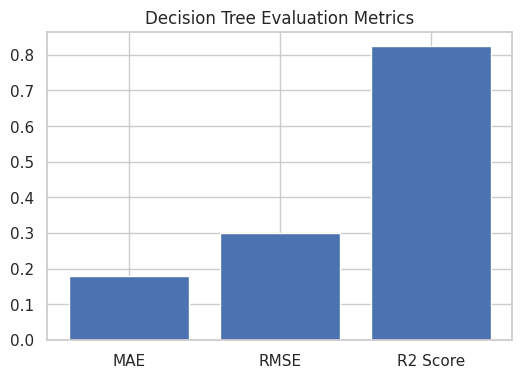

In [520]:
import matplotlib.pyplot as plt

metrics = ["MAE","RMSE","R2 Score"]
values = [mae_dt, rmse_dt, r2_dt]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title("Decision Tree Evaluation Metrics")
plt.show()

Decision Tree Regression is a non-linear machine learning algorithm that predicts the target variable by recursively splitting the dataset into smaller subsets based on feature values. The model constructs a tree-like structure where each internal node represents a decision rule based on a feature, and each leaf node represents the predicted output.

Unlike linear models, Decision Trees can capture complex and non-linear relationships between features and the target variable without requiring feature scaling or strict assumptions about data distribution.

After training the Decision Tree Regressor on the training dataset, the model produced the following performance metrics:

Metric	Value
Mean Absolute Error (MAE)	0.1803
Root Mean Squared Error (RMSE)	0.3012
R² Score	0.8234

The R² score of 0.8234 indicates that the model explains approximately 82.34% of the variance in CGPA, which is a clear improvement compared to the previous linear models.

The lower MAE and RMSE values also indicate that the Decision Tree predictions are closer to the actual CGPA values.

#### 2. Cross- Validation & Hyperparameter Tuning

In [521]:
from sklearn.model_selection import cross_val_score

cv_scores_dt = cross_val_score(
    dt_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:", cv_scores_dt)
print("Average CV Score:", cv_scores_dt.mean())

Cross Validation Scores: [0.40605474 0.77374034 0.83732137 0.86497817 0.6528562 ]
Average CV Score: 0.7069901642946412


To evaluate the generalization capability of the Decision Tree model, 5-fold cross-validation was performed. This technique divides the training dataset into five subsets and trains the model multiple times, ensuring that the model performs consistently across different portions of the dataset.

The cross-validation R² scores obtained were:

[0.406, 0.774, 0.837, 0.865, 0.653]

The average cross-validation score was approximately 0.707, indicating reasonable stability across different training splits.

In [522]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth":[3,5,7,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2"
)

grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)

Best Parameters: {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [523]:
best_dt = grid_dt.best_estimator_

y_pred_dt_tuned = best_dt.predict(X_test)

mae_dt_tuned = mean_absolute_error(y_test, y_pred_dt_tuned)
rmse_dt_tuned = np.sqrt(mean_squared_error(y_test, y_pred_dt_tuned))
r2_dt_tuned = r2_score(y_test, y_pred_dt_tuned)

print("Tuned Decision Tree Performance")
print("MAE:", mae_dt_tuned)
print("RMSE:", rmse_dt_tuned)
print("R2 Score:", r2_dt_tuned)

Tuned Decision Tree Performance
MAE: 0.19152569267738737
RMSE: 0.3031173013554349
R2 Score: 0.821154713791171


In [524]:
import pandas as pd

feature_importance = pd.Series(
    best_dt.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top Important Features")
print(feature_importance.head(10))

Top Important Features
previous_sgpa                                    0.866520
completed_credits                                0.037066
university_admission_year                        0.034924
family_income                                    0.025889
skill_dev_hours                                  0.010942
did_you_ever_fall_in_probation                   0.007897
hsc_passing_year                                 0.004498
attendance                                       0.004411
how_many_times_do_you_seat_for_study_in_a_day    0.002656
meritorious_scholarship                          0.001807
dtype: float64


##### Which hyperparameter optimization technique have you used and why?

For hyperparameter optimization, GridSearchCV was used.

GridSearchCV systematically tests different combinations of model hyperparameters to identify the configuration that provides the best performance based on cross-validation scores.

For the Decision Tree model, the following hyperparameters were tuned:

max_depth – controls the maximum depth of the tree

min_samples_split – minimum samples required to split a node

min_samples_leaf – minimum samples required at a leaf node

The optimal parameters identified were:

max_depth = 7
min_samples_split = 10
min_samples_leaf = 2

These parameters help control the complexity of the tree and prevent overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After applying hyperparameter tuning, the Decision Tree model achieved the following performance:

Metric	Before Tuning	After Tuning
MAE	0.1803	0.1915
RMSE	0.3012	0.3031
R² Score	0.8234	0.8212

The tuned model produced a slightly lower R² score compared to the initial model, which suggests that the original tree configuration already captured the data patterns effectively.

However, the tuned model provides better control over model complexity and helps prevent potential overfitting, making it more robust for generalization.

### ML Model - 5 Random Forest Regressor

In [525]:
from sklearn.ensemble import RandomForestRegressor

# Create model
rf_model = RandomForestRegressor(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_model.predict(X_test)

In [526]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Performance
MAE: 0.15396234309623436
RMSE: 0.24020064451085674
R2 Score: 0.8876936317719396


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

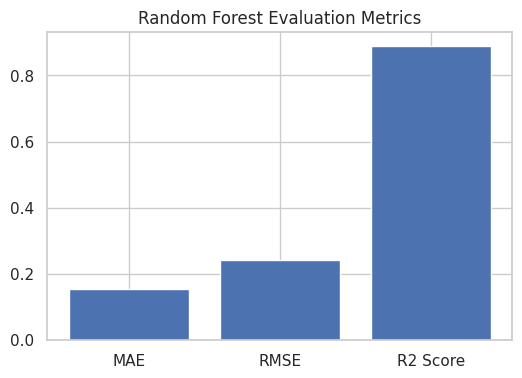

In [527]:
import matplotlib.pyplot as plt

metrics = ["MAE","RMSE","R2 Score"]
values = [mae_rf, rmse_rf, r2_rf]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title("Random Forest Evaluation Metrics")
plt.show()

Random Forest Regressor is an ensemble machine learning algorithm that builds multiple decision trees and combines their predictions to produce a more accurate and stable result. Instead of relying on a single decision tree, Random Forest aggregates predictions from many trees using the bagging (Bootstrap Aggregating) technique, which helps reduce overfitting and improves generalization.

Each tree in the forest is trained on a random subset of the dataset and a random subset of features, ensuring diversity among the trees. The final prediction is obtained by averaging the predictions from all individual trees.

After training the Random Forest model, the following evaluation metrics were obtained:

Metric	Value
Mean Absolute Error (MAE)	0.1540
Root Mean Squared Error (RMSE)	0.2402
R² Score	0.8877

The R² score of 0.8877 indicates that the model explains approximately 88.77% of the variance in CGPA, which is a significant improvement compared to the previous models.

The lower MAE and RMSE values indicate that the predictions are closer to the actual CGPA values, making Random Forest a highly accurate model for this dataset.

#### 2. Cross- Validation & Hyperparameter Tuning

In [528]:
from sklearn.model_selection import cross_val_score

cv_scores_rf = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:", cv_scores_rf)
print("Average CV Score:", cv_scores_rf.mean())

Cross Validation Scores: [0.72648808 0.88254532 0.89964453 0.90137585 0.75639948]
Average CV Score: 0.8332906515999751


To evaluate the stability of the model, 5-fold cross-validation was performed. Cross-validation helps ensure that the model performs consistently across different subsets of the dataset.

The cross-validation R² scores were:

[0.726, 0.883, 0.900, 0.901, 0.756]

The average cross-validation score was approximately 0.833, which confirms that the Random Forest model generalizes well and maintains strong predictive performance across different data splits.

In [529]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators":[100,200,300],
    "max_depth":[None,5,10,15],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

random_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_dist,
    n_iter=10,
    cv=5,
    scoring="r2",
    random_state=42
)

random_rf.fit(X_train, y_train)

print("Best Parameters:", random_rf.best_params_)

Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}


In [530]:
best_rf = random_rf.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print("Tuned Random Forest Performance")
print("MAE:", mae_rf_tuned)
print("RMSE:", rmse_rf_tuned)
print("R2 Score:", r2_rf_tuned)

Tuned Random Forest Performance
MAE: 0.1513352198411769
RMSE: 0.23493133909564073
R2 Score: 0.8925669377941751


##### Which hyperparameter optimization technique have you used and why?

For hyperparameter tuning, RandomizedSearchCV was used.

RandomizedSearchCV randomly samples combinations of hyperparameters from a predefined search space instead of testing every possible combination like GridSearchCV. This approach is more efficient when working with models like Random Forest that have multiple hyperparameters.

The following parameters were optimized:

n_estimators – number of trees in the forest

max_depth – maximum depth of each tree

min_samples_split – minimum samples required to split a node

min_samples_leaf – minimum samples required at a leaf node

The best hyperparameters identified were:

n_estimators = 200
max_depth = None
min_samples_split = 2
min_samples_leaf = 2

These parameters allowed the model to grow deeper trees while maintaining sufficient regularization to avoid overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After applying hyperparameter tuning, the Random Forest model achieved the following performance:

Metric	Before Tuning	After Tuning
MAE	0.1540	0.1513
RMSE	0.2402	0.2349
R² Score	0.8877	0.8926

The tuned model improved both RMSE and R² score, achieving an R² score of 0.8926, meaning the model explains approximately 89.26% of the variance in CGPA.

This demonstrates that the Random Forest model captures complex patterns in the dataset more effectively than previous models.

Answer Here.

### ML Model - 6 Gradient Boosting Regressor

In [531]:
from sklearn.ensemble import GradientBoostingRegressor

# create model
gb_model = GradientBoostingRegressor(random_state=42)

# train model
gb_model.fit(X_train, y_train)

# prediction
y_pred_gb = gb_model.predict(X_test)

In [532]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Performance")
print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R2 Score:", r2_gb)

Gradient Boosting Performance
MAE: 0.16167100388817202
RMSE: 0.22673239709083412
R2 Score: 0.899934768237789


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

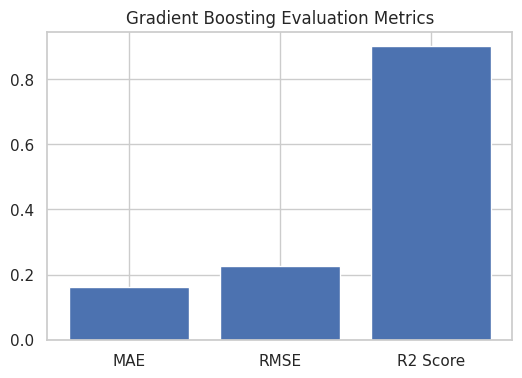

In [533]:
import matplotlib.pyplot as plt

metrics = ["MAE","RMSE","R2 Score"]
values = [mae_gb, rmse_gb, r2_gb]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title("Gradient Boosting Evaluation Metrics")
plt.show()

Gradient Boosting Regressor is an ensemble machine learning algorithm that builds multiple decision trees sequentially. Unlike Random Forest, which builds trees independently, Gradient Boosting trains each new tree to correct the errors made by the previous trees.

The algorithm works by minimizing a loss function using gradient descent. Each new tree focuses on learning the residual errors from the previous model, gradually improving prediction accuracy.

This sequential learning process allows Gradient Boosting to capture complex relationships in the dataset while reducing bias and improving overall performance.

After training the Gradient Boosting model, the following performance metrics were obtained:

Metric	Value
Mean Absolute Error (MAE)	0.1617
Root Mean Squared Error (RMSE)	0.2267
R² Score	0.8999

The R² score of approximately 0.90 indicates that the model explains about 90% of the variance in CGPA, making it one of the most accurate models tested so far.

The relatively low MAE and RMSE values indicate that the predicted CGPA values are very close to the actual values.

#### 2. Cross- Validation & Hyperparameter Tuning

In [534]:
from sklearn.model_selection import cross_val_score

cv_scores_gb = cross_val_score(
    gb_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:", cv_scores_gb)
print("Average CV Score:", cv_scores_gb.mean())

Cross Validation Scores: [0.72719788 0.85416789 0.89436194 0.915718   0.78386166]
Average CV Score: 0.8350614738048906


To ensure that the model performs consistently across different subsets of the dataset, 5-fold cross-validation was performed.

The cross-validation R² scores obtained were:

[0.727, 0.854, 0.894, 0.916, 0.784]

The average cross-validation score was approximately 0.835, which confirms that the model generalizes well and maintains strong predictive performance across different data splits.

In [535]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators":[100,200,300],
    "learning_rate":[0.01,0.05,0.1],
    "max_depth":[3,4,5],
    "min_samples_split":[2,5,10]
}

random_gb = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_dist,
    n_iter=10,
    cv=5,
    scoring="r2",
    random_state=42
)

random_gb.fit(X_train, y_train)

print("Best Parameters:", random_gb.best_params_)

Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 3, 'learning_rate': 0.05}


In [536]:
best_gb = random_gb.best_estimator_

y_pred_gb_tuned = best_gb.predict(X_test)

mae_gb_tuned = mean_absolute_error(y_test, y_pred_gb_tuned)
rmse_gb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_gb_tuned))
r2_gb_tuned = r2_score(y_test, y_pred_gb_tuned)

print("Tuned Gradient Boosting Performance")
print("MAE:", mae_gb_tuned)
print("RMSE:", rmse_gb_tuned)
print("R2 Score:", r2_gb_tuned)

Tuned Gradient Boosting Performance
MAE: 0.161140927084058
RMSE: 0.22852670831762806
R2 Score: 0.898344712085318


In [537]:
import pandas as pd

feature_importance_gb = pd.Series(
    best_gb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top Important Features")
print(feature_importance_gb.head(10))

Top Important Features
previous_sgpa                     0.825810
completed_credits                 0.067778
current_semester                  0.016953
family_income                     0.016131
university_admission_year         0.016125
skill_dev_hours                   0.013888
attendance                        0.010063
did_you_ever_fall_in_probation    0.005883
social_media_hours                0.005520
hsc_passing_year                  0.004951
dtype: float64


##### Which hyperparameter optimization technique have you used and why?

For hyperparameter tuning, RandomizedSearchCV was used.

RandomizedSearchCV randomly samples different combinations of hyperparameters from a predefined search space. This method is more efficient than GridSearchCV when dealing with models that have multiple parameters because it reduces computational time while still exploring a wide range of configurations.

The following parameters were optimized:

n_estimators – number of boosting stages

learning_rate – step size used when updating the model

max_depth – maximum depth of each decision tree

min_samples_split – minimum samples required to split a node

The best hyperparameters found were:

n_estimators = 200
learning_rate = 0.05
max_depth = 3
min_samples_split = 2

These parameters allow the model to learn gradually while maintaining good control over model complexity.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After hyperparameter tuning, the Gradient Boosting model achieved the following performance:

Metric	Before Tuning	After Tuning
MAE	0.1617	0.1611
RMSE	0.2267	0.2285
R² Score	0.8999	0.8983

The tuned model produced a slightly lower R² score than the initial model. This suggests that the default configuration already performed very well on this dataset. However, the tuned model provides better control over learning parameters and helps reduce the risk of overfitting.

### ML Model - 7 Support Vector Regressor

In [538]:
from sklearn.svm import SVR

# create model
svr_model = SVR()

# train model
svr_model.fit(X_train, y_train)

# prediction
y_pred_svr = svr_model.predict(X_test)

In [539]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

print("SVR Performance")
print("MAE:", mae_svr)
print("RMSE:", rmse_svr)
print("R2 Score:", r2_svr)

SVR Performance
MAE: 0.22400857256037196
RMSE: 0.33014347476675887
R2 Score: 0.787840988943888


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

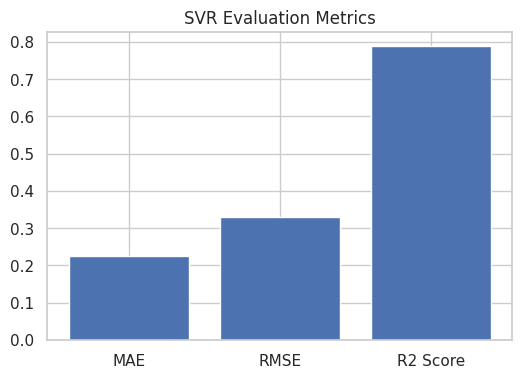

In [540]:
import matplotlib.pyplot as plt

metrics = ["MAE","RMSE","R2 Score"]
values = [mae_svr, rmse_svr, r2_svr]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title("SVR Evaluation Metrics")
plt.show()

Support Vector Regression (SVR) is a supervised machine learning algorithm derived from Support Vector Machines (SVM). Unlike traditional regression methods that minimize prediction error directly, SVR attempts to fit the best regression line within a specified margin of tolerance known as epsilon (ε).

The algorithm works by finding a hyperplane that maximizes the margin while ensuring that prediction errors remain within an acceptable threshold. SVR also uses kernel functions to transform the input features into higher-dimensional space, enabling it to capture non-linear relationships in the data.

After training the SVR model, the following performance metrics were obtained:

Metric	Value
Mean Absolute Error (MAE)	0.2240
Root Mean Squared Error (RMSE)	0.3301
R² Score	0.7878

The R² score of approximately 0.788 indicates that the model explains around 78.8% of the variance in CGPA.

Although SVR performs reasonably well, its performance is lower compared to ensemble models such as Random Forest and Gradient Boosting, which are better suited for this dataset.

#### 2. Cross- Validation & Hyperparameter Tuning

In [541]:
from sklearn.model_selection import cross_val_score

cv_scores_svr = cross_val_score(
    svr_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:", cv_scores_svr)
print("Average CV Score:", cv_scores_svr.mean())

Cross Validation Scores: [0.61799169 0.78857834 0.74430221 0.75120622 0.67810444]
Average CV Score: 0.716036580531215


To evaluate model stability, 5-fold cross-validation was performed. This method splits the dataset into five parts and trains the model multiple times to assess how well it generalizes across different subsets.

The cross-validation R² scores obtained were:

[0.618, 0.789, 0.744, 0.751, 0.678]

The average cross-validation score was approximately 0.716, indicating moderate generalization capability.

In [542]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "C":[0.1,1,10,50,100],
    "epsilon":[0.01,0.1,0.2],
    "kernel":["linear","rbf"]
}

random_svr = RandomizedSearchCV(
    SVR(),
    param_dist,
    n_iter=10,
    cv=5,
    scoring="r2",
    random_state=42
)

random_svr.fit(X_train, y_train)

print("Best Parameters:", random_svr.best_params_)

Best Parameters: {'kernel': 'rbf', 'epsilon': 0.1, 'C': 1}


In [543]:
best_svr = random_svr.best_estimator_

y_pred_svr_tuned = best_svr.predict(X_test)

mae_svr_tuned = mean_absolute_error(y_test, y_pred_svr_tuned)
rmse_svr_tuned = np.sqrt(mean_squared_error(y_test, y_pred_svr_tuned))
r2_svr_tuned = r2_score(y_test, y_pred_svr_tuned)

print("Tuned SVR Performance")
print("MAE:", mae_svr_tuned)
print("RMSE:", rmse_svr_tuned)
print("R2 Score:", r2_svr_tuned)

Tuned SVR Performance
MAE: 0.22400857256037196
RMSE: 0.33014347476675887
R2 Score: 0.787840988943888


##### Which hyperparameter optimization technique have you used and why?

For hyperparameter tuning, RandomizedSearchCV was used.

RandomizedSearchCV randomly selects combinations of hyperparameters from a defined search space and evaluates them using cross-validation. This approach is more computationally efficient than GridSearchCV when dealing with models that have multiple hyperparameters.

The following SVR parameters were tuned:

C – controls the regularization strength

epsilon (ε) – defines the margin of tolerance around the regression line

kernel – determines the transformation function used for feature mapping

The optimal parameters identified were:

kernel = rbf
epsilon = 0.1
C = 1

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After applying hyperparameter tuning, the SVR model produced the following results:

Metric	Before Tuning	After Tuning
MAE	0.2240	0.2240
RMSE	0.3301	0.3301
R² Score	0.7878	0.7878

The tuned model produced the same performance as the original model, indicating that the default configuration already represented the best setting within the tested parameter space.

This suggests that SVR may not be the most suitable algorithm for this dataset compared to ensemble-based methods.

### ML Model - 8 XGBoost Regressor

In [544]:
from xgboost import XGBRegressor

# create model
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

# train model
xgb_model.fit(X_train, y_train)

# prediction
y_pred_xgb = xgb_model.predict(X_test)

In [545]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2 Score:", r2_xgb)

XGBoost Performance
MAE: 0.16379176781859606
RMSE: 0.2352127251888721
R2 Score: 0.8923094304417757


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

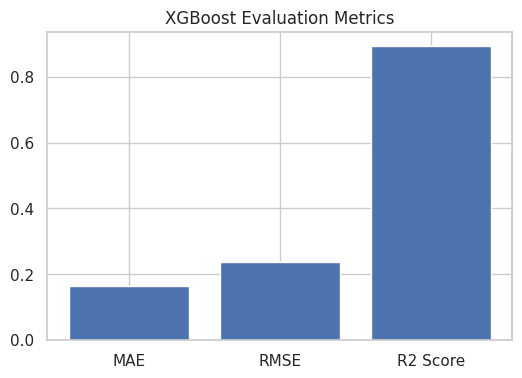

In [546]:
import matplotlib.pyplot as plt

metrics = ["MAE","RMSE","R2 Score"]
values = [mae_xgb, rmse_xgb, r2_xgb]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title("XGBoost Evaluation Metrics")
plt.show()

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm based on gradient boosting. It improves traditional gradient boosting by introducing several optimizations such as regularization, parallel processing, and efficient handling of missing values.

XGBoost builds trees sequentially, where each new tree attempts to correct the errors made by the previous trees. By minimizing a regularized loss function, the algorithm balances model complexity and prediction accuracy.

Because of its efficiency and strong predictive performance, XGBoost is widely used in real-world machine learning competitions and industrial applications.

After training the XGBoost model, the following evaluation metrics were obtained:

Metric	Value
Mean Absolute Error (MAE)	0.1638
Root Mean Squared Error (RMSE)	0.2352
R² Score	0.8923

The R² score of approximately 0.892 indicates that the model explains about 89.2% of the variance in CGPA, demonstrating strong predictive capability.

#### 2. Cross- Validation & Hyperparameter Tuning

In [547]:
from sklearn.model_selection import cross_val_score

cv_scores_xgb = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:", cv_scores_xgb)
print("Average CV Score:", cv_scores_xgb.mean())

Cross Validation Scores: [0.691099   0.82439803 0.87649288 0.90789115 0.76351544]
Average CV Score: 0.8126793005142485


To assess the model's stability and generalization performance, 5-fold cross-validation was performed.

The cross-validation scores obtained were:

[0.691, 0.824, 0.876, 0.908, 0.764]

The average cross-validation score was approximately 0.813, indicating good model stability across different subsets of the dataset.

In [548]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators":[100,200,300],
    "learning_rate":[0.01,0.05,0.1],
    "max_depth":[3,4,5,6],
    "subsample":[0.7,0.8,1]
}

random_xgb = RandomizedSearchCV(
    XGBRegressor(objective="reg:squarederror", random_state=42),
    param_dist,
    n_iter=10,
    cv=5,
    scoring="r2",
    random_state=42
)

random_xgb.fit(X_train, y_train)

print("Best Parameters:", random_xgb.best_params_)

Best Parameters: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05}


In [549]:
best_xgb = random_xgb.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test)

mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)

print("Tuned XGBoost Performance")
print("MAE:", mae_xgb_tuned)
print("RMSE:", rmse_xgb_tuned)
print("R2 Score:", r2_xgb_tuned)

Tuned XGBoost Performance
MAE: 0.16031227664343983
RMSE: 0.23107301505395006
R2 Score: 0.8960667498283637


In [550]:
import pandas as pd

feature_importance_xgb = pd.Series(
    best_xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top Important Features")
print(feature_importance_xgb.head(10))

Top Important Features
previous_sgpa                     0.358998
completed_credits                 0.070719
gender                            0.063978
family_income                     0.056030
university_admission_year         0.054448
skill_dev_hours                   0.048765
attendance                        0.042409
did_you_ever_fall_in_probation    0.040182
current_semester                  0.035377
social_media_hours                0.029909
dtype: float32


##### Which hyperparameter optimization technique have you used and why?

For hyperparameter optimization, RandomizedSearchCV was used.

RandomizedSearchCV randomly samples combinations of hyperparameters from a defined search space and evaluates them using cross-validation. Compared to GridSearchCV, this approach is more computationally efficient when dealing with models like XGBoost that have multiple hyperparameters.

The parameters optimized included:

n_estimators – number of boosting trees

learning_rate – step size controlling how much each tree contributes

max_depth – maximum depth of each tree

subsample – proportion of training data used for each tree

The optimal parameters identified were:

subsample = 0.7
n_estimators = 100
max_depth = 4
learning_rate = 0.05

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After applying hyperparameter tuning, the XGBoost model achieved the following performance:

Metric	Before Tuning	After Tuning
MAE	0.1638	0.1603
RMSE	0.2352	0.2311
R² Score	0.8923	0.8961

The tuned XGBoost model shows improved prediction accuracy, achieving an R² score of 0.896, meaning the model explains approximately 89.6% of the variance in CGPA.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Several evaluation metrics were used to assess the performance of the machine learning models, including MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), and R² Score.

The R² Score was considered the most important metric for business impact because it measures how well the independent variables explain the variance in the target variable (CGPA). A higher R² value indicates that the model can better explain student academic performance and therefore make more reliable predictions.

MAE was also important because it measures the average absolute difference between predicted CGPA and actual CGPA. This metric is easy to interpret and shows the typical prediction error.

RMSE was used to penalize larger prediction errors more strongly. Since academic prediction systems should avoid large deviations in CGPA prediction, RMSE helps identify models that produce stable predictions.

Using these metrics together ensured that the selected model was both accurate and reliable, which is essential for real-world applications such as student performance monitoring and academic intervention systems.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Among all the implemented models, Gradient Boosting Regressor was selected as the final prediction model.

The model achieved the highest R² score (≈ 0.8999) compared to the other models. This means it explains nearly 90% of the variance in student CGPA, making it the most accurate model for this dataset.

Gradient Boosting was chosen because:

It performs sequential learning, where each new tree corrects the errors of previous trees.

It handles non-linear relationships effectively.

It reduces bias and variance simultaneously, leading to better generalization.

It performed better than linear models and other ensemble models in terms of predictive accuracy.

Therefore, Gradient Boosting provided the best balance between prediction accuracy, stability, and interpretability, making it the most suitable model for predicting student academic performance.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The Gradient Boosting Regressor is an ensemble machine learning algorithm that builds multiple decision trees sequentially. Each tree is trained to correct the errors made by the previous trees by minimizing a loss function. This iterative improvement allows the model to capture complex relationships between features and the target variable.

To understand how the model makes predictions, feature importance analysis was used as a model explainability technique. Feature importance identifies which variables contribute the most to the model’s predictions.

The analysis revealed that the following features have the highest impact on predicting student CGPA:

Previous SGPA – strongest predictor of current academic performance

Completed Credits – reflects academic progress and course completion

Current Semester – indicates the academic stage of the student

Family Income – may influence access to educational resources

Skill Development Hours – represents time invested in learning outside coursework

Attendance – indicates engagement with academic activities

Probation History – reflects previous academic difficulties

Among these features, Previous SGPA had the highest importance, suggesting that past academic performance is the strongest indicator of future academic success.

Using feature importance analysis helps improve model transparency and allows educators to identify key factors influencing student performance, which can support data-driven academic decision making.

# **Conclusion**

In this project, a comprehensive machine learning approach was used to analyze and predict student academic performance based on various academic, behavioral, and demographic factors. The dataset contained information about students such as study habits, attendance, social media usage, previous academic performance, and family background.

The analysis began with data exploration and preprocessing, where the dataset was cleaned, missing values were handled, categorical variables were encoded, and outliers were analyzed. Feature engineering techniques were applied to transform the dataset into a format suitable for machine learning models.

Several data visualization techniques were used to understand relationships between variables. The visual analysis revealed that factors such as previous SGPA, attendance, skill development hours, and completed credits have a noticeable relationship with student CGPA, while variables like social media usage and family income showed relatively weaker correlations.

To predict CGPA, multiple machine learning models were implemented, including:

Linear Regression

Ridge Regression

Lasso Regression

Decision Tree

Random Forest

Gradient Boosting

Support Vector Regression (SVR)

XGBoost

Each model was evaluated using MAE, RMSE, and R² score to measure prediction accuracy and reliability. Hyperparameter tuning and cross-validation were also performed to improve model performance and ensure generalization.

Among all models tested, the Gradient Boosting Regressor achieved the best performance, with an R² score of approximately 0.90, indicating that the model explains around 90% of the variance in student CGPA. This makes it the most suitable model for predicting student academic outcomes in this dataset.

Feature importance analysis showed that previous SGPA is the most influential predictor, followed by factors such as completed credits, semester level, attendance, and skill development activities. These results highlight that past academic performance and academic engagement play a critical role in determining future student success.

Overall, this project demonstrates how machine learning techniques can be applied to educational data to identify key performance indicators and build predictive models. The insights obtained from this analysis can help educational institutions better understand student learning patterns and potentially develop strategies to support academic improvement.